In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, chi2
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files


uploaded = files.upload()
for fn in uploaded.keys():
    INPUT_CSV = fn
    print("Using:", INPUT_CSV)



Saving framingham_cleaned (1).csv to framingham_cleaned (1) (1).csv
Using: framingham_cleaned (1) (1).csv


In [ ]:
df = pd.read_csv(INPUT_CSV)
df = df.dropna()

target_column = "TenYearCHD"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"✅ X and y are ready!")
print(f"   Rows: {df.shape[0]} | Features: {X.shape[1]}")
print(f"   Target distribution:\n{y.value_counts()}")

✅ X and y are ready!
   Rows: 3658 | Features: 15
   Target distribution:
TenYearCHD
0    3101
1     557
Name: count, dtype: int64


In [ ]:
def preprocess_features(df, target_col):
    """
    Returns:
      - X_encoded: preprocessed features (encoded + scaled) as DataFrame
      - y: target Series
      - numeric_for_scaling: list of numeric columns scaled
      - label_encoders: dict of LabelEncoder for binary categorical cols
      - scaler: fitted StandardScaler
      - num_imputer, cat_imputer: fitted imputers (handy for inference)
    """
    # Separate X and y
    y = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()

    # Identify numeric and categorical columns
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # Treat low-cardinality numeric as categorical (heuristic)
    for col in numeric_cols[:]:
        if X[col].nunique(dropna=True) <= 6:
            numeric_cols.remove(col)
            categorical_cols.append(col)


    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')

    if numeric_cols:
        X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
    if categorical_cols:
        X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])


    X_encoded = X.copy()
    label_encoders = {}
    onehot_cols = []
    for col in categorical_cols:
        n_unique = X_encoded[col].nunique(dropna=True)
        if n_unique <= 2:
            le = LabelEncoder()
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
            label_encoders[col] = le
        else:
            onehot_cols.append(col)

    if onehot_cols:
        X_encoded = pd.get_dummies(X_encoded, columns=onehot_cols, drop_first=True)


    scaler = StandardScaler()
    numeric_for_scaling = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_for_scaling:
        X_encoded[numeric_for_scaling] = scaler.fit_transform(X_encoded[numeric_for_scaling])

    if X_encoded.isna().any().any():
        X_encoded = X_encoded.fillna(0)

    return X_encoded, y, numeric_for_scaling, label_encoders, scaler, num_imputer, cat_imputer


In [ ]:
def detect_target(df):

    possible_targets = ['target', 'TenYearCHD', 'CHD', 'Outcome', 'label', 'y']
    for c in possible_targets:
        if c in df.columns:
            return c
    return df.columns[-1]


In [ ]:
def detect_target(df):
    possible_targets = ['target', 'TenYearCHD', 'CHD', 'Outcome', 'label', 'y']
    for c in possible_targets:
        if c in df.columns:
            return c
    return df.columns[-1]

def is_classification_target(y):
    if pd.api.types.is_integer_dtype(y) or pd.api.types.is_object_dtype(y) or pd.api.types.is_bool_dtype(y):
        if y.nunique() <= 20:
            return True
    if pd.api.types.is_float_dtype(y) and y.nunique() <= 20:
        return True
    return False

def rank_by_correlation(X, y):
    corrs = {}
    y_num = pd.to_numeric(y, errors='coerce')
    for col in X.columns:
        try:
            if pd.api.types.is_numeric_dtype(X[col]) and pd.api.types.is_numeric_dtype(y_num):
                corr = abs(np.corrcoef(X[col].astype(float), y_num.astype(float))[0,1])
                if np.isnan(corr):
                    corr = 0.0
            else:
                corr = 0.0
        except Exception:
            corr = 0.0
        corrs[col] = corr
    return pd.Series(corrs)

def rank_by_mutual_info(X, y, classification=True):
    X_arr = X.values
    if classification:
        y_arr = y.astype('int').values
        mi = mutual_info_classif(X_arr, y_arr, random_state=42)
    else:
        y_arr = pd.to_numeric(y, errors='coerce').values
        mi = mutual_info_regression(X_arr, y_arr, random_state=42)
    return pd.Series(mi, index=X.columns)

def rank_by_chi2(X, y):
    try:
        X_mm = MinMaxScaler().fit_transform(np.abs(X.values))
        y_num = y.astype('int').values
        chi2_vals, pvals = chi2(X_mm, y_num)
        return pd.Series(chi2_vals, index=X.columns)
    except Exception:
        return pd.Series(0.0, index=X.columns)

def rank_by_tree_importance(X_train, y_train, classification=True):
    if classification:
        model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    else:
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    return importances, model

def rank_by_permutation(model, X_val, y_val, n_repeats=10):
    r = permutation_importance(model, X_val, y_val, n_repeats=n_repeats, random_state=42, n_jobs=-1)
    return pd.Series(r.importances_mean, index=X_val.columns)

def aggregate_rankings(ranking_series_dict):
    df = pd.DataFrame(ranking_series_dict)
    normalized = (df - df.min()) / (df.max() - df.min()).replace(0, 1)
    aggregated = normalized.mean(axis=1)
    result = pd.DataFrame({'aggregated_score': aggregated}).sort_values('aggregated_score', ascending=False)
    result = result.join(df)
    return result


In [ ]:

#feature ranking
import os, warnings
warnings.filterwarnings('ignore')

# ── Guard ─────────────────────────────────────────────────────────────────────
try:
    INPUT_CSV
except NameError:
    raise RuntimeError("❌ Run Cell 1 (file upload) first so INPUT_CSV is defined.")

import numpy as np
import pandas as pd
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, chi2
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

IN_COLAB = True
TOP_N    = 10

def detect_target(df):
    """Heuristic: last column, or column named 'target'/'label'/'class'."""
    for name in ['target','label','class','Target','Label','Class']:
        if name in df.columns:
            return name
    return df.columns[-1]

def is_classification_target(y):
    if y.dtype == object or str(y.dtype) == 'category':
        return True
    return y.nunique() <= 20

def preprocess_features(df, target_col):
    df = df.copy()
    y_raw = df.pop(target_col)

    # Encode target if needed
    if y_raw.dtype == object or str(y_raw.dtype) == 'category':
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y_raw.astype(str)), name=target_col)
    else:
        y = y_raw.reset_index(drop=True)

    cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    label_encoders = {}
    cat_imputer    = SimpleImputer(strategy='most_frequent')
    num_imputer    = SimpleImputer(strategy='mean')

    if cat_cols:
        df[cat_cols] = cat_imputer.fit_transform(df[cat_cols].astype(str))
        for col in cat_cols:
            le2 = LabelEncoder()
            df[col] = le2.fit_transform(df[col])
            label_encoders[col] = le2

    if num_cols:
        df[num_cols] = num_imputer.fit_transform(df[num_cols])

    scaler = StandardScaler()
    df[df.columns] = scaler.fit_transform(df)
    numeric_scaled_cols = df.columns.tolist()

    X = df.reset_index(drop=True)
    y = y.reset_index(drop=True)
    return X, y, numeric_scaled_cols, label_encoders, scaler, num_imputer, cat_imputer

def rank_by_correlation(X, y):
    scores = X.apply(lambda col: abs(col.corr(y)))
    return scores.fillna(0)

def rank_by_mutual_info(X, y, classification=True):
    fn = mutual_info_classif if classification else mutual_info_regression
    vals = fn(X, y, random_state=42)
    return pd.Series(vals, index=X.columns).fillna(0)

def rank_by_chi2(X, y):
    scaler_chi = MinMaxScaler()
    X_pos = pd.DataFrame(scaler_chi.fit_transform(X), columns=X.columns)
    scores, _ = chi2(X_pos, y)
    return pd.Series(scores, index=X.columns).fillna(0)

def rank_by_tree_importance(X_train, y_train, classification=True):
    clf = (RandomForestClassifier(n_estimators=100, random_state=42)
           if classification else
           __import__('sklearn.ensemble',fromlist=['RandomForestRegressor']).RandomForestRegressor(n_estimators=100,random_state=42))
    clf.fit(X_train, y_train)
    return pd.Series(clf.feature_importances_, index=X_train.columns).fillna(0), clf

def rank_by_permutation(model, X_val, y_val, n_repeats=10):
    result = permutation_importance(model, X_val, y_val,
                                    n_repeats=n_repeats, random_state=42, n_jobs=-1)
    return pd.Series(result.importances_mean, index=X_val.columns).fillna(0)

# ── 1. Load & preprocess ──────────────────────────────────────────────────────
print("INPUT_CSV =", INPUT_CSV)
df = pd.read_csv(INPUT_CSV)
print("Loaded shape:", df.shape)

target_col = detect_target(df)
print("Target:", target_col)

X, y, numeric_scaled_cols, label_encoders, scaler, num_imputer, cat_imputer = preprocess_features(df, target_col)
print("X shape:", X.shape)

classification = is_classification_target(y)
print("Task:", "Classification" if classification else "Regression")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if classification and y.nunique() > 1 else None
)


print("\n[1/5] Pearson...")
corr_scores = rank_by_correlation(X, y)

print("[2/5] Mutual Information...")
mi_scores = rank_by_mutual_info(X, y, classification=classification)

print("[3/5] Chi-Square...")
chi2_scores = rank_by_chi2(X, y) if classification else pd.Series(0.0, index=X.columns)

print("[4/5] RF Importance...")
rf_importances, rf_model = rank_by_tree_importance(X_train, y_train, classification=classification)

print("[5/5] Permutation...")
try:
    perm_scores = rank_by_permutation(rf_model, X_val, y_val, n_repeats=10)
except Exception as e:
    print("  Permutation failed:", e)
    perm_scores = pd.Series(0.0, index=X.columns)


for s in [corr_scores, mi_scores, chi2_scores, rf_importances, perm_scores]:
    for col in X.columns:
        if col not in s.index:
            s.loc[col] = 0.0
corr_scores    = corr_scores[X.columns]
mi_scores      = mi_scores[X.columns]
chi2_scores    = chi2_scores[X.columns]
rf_importances = rf_importances[X.columns]
perm_scores    = perm_scores[X.columns]


METHODS = [
    ('RF Importance',       rf_importances,  'rf_importance',   'ranking_rf_importance.csv'),
    ('Pearson Correlation', corr_scores,     'pearson_abs',     'ranking_pearson.csv'),
    ('Mutual Information',  mi_scores,       'mutual_info',     'ranking_mutual_info.csv'),
    ('Chi-Square',          chi2_scores,     'chi2',            'ranking_chi2.csv'),
    ('Permutation',         perm_scores,     'perm_importance', 'ranking_permutation.csv'),
]

ranking_frames = {}
saved_csvs     = []

print("\n" + "="*70)
print("FEATURE RANKINGS — each sorted by its OWN score")
print("="*70)

for label, scores, col_name, fname in METHODS:
    df_rank = (pd.DataFrame({'Feature': X.columns, col_name: scores.values})
               .sort_values(col_name, ascending=False)
               .reset_index(drop=True))
    df_rank.index      = df_rank.index + 1
    df_rank.index.name = 'Rank'
    ranking_frames[label] = df_rank

    print(f"\n── {label} ──")
    print(df_rank.to_string())

    path = f'/content/{fname}'
    df_rank.to_csv(path)
    saved_csvs.append(path)
    print(f"✓ Saved: {path}")

# Combined ranking CSV
combined_ranking = pd.DataFrame({'Feature': X.columns.tolist()})
for label, scores, col_name, _ in METHODS:
    combined_ranking[col_name]           = scores.values
    combined_ranking[col_name + '_rank'] = combined_ranking[col_name].rank(ascending=False).astype(int)
combined_rank_path = '/content/feature_ranking_all_methods.csv'
combined_ranking.to_csv(combined_rank_path, index=False)
saved_csvs.append(combined_rank_path)
print(f"\n✓ Combined ranking: {combined_rank_path}")


classifiers_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42),
    'LDA':                 LinearDiscriminantAnalysis(),
    'QDA':                 QuadraticDiscriminantAnalysis(),
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42),
}
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(X_sub, y, clfs, cv):
    rows = []
    for name, clf in clfs.items():
        try:
            acc  = cross_val_score(clf, X_sub, y, cv=cv, scoring='accuracy',  n_jobs=-1).mean()
            prec = cross_val_score(clf, X_sub, y, cv=cv, scoring='precision_weighted', n_jobs=-1).mean()
            rec  = cross_val_score(clf, X_sub, y, cv=cv, scoring='recall_weighted',    n_jobs=-1).mean()
            f1   = cross_val_score(clf, X_sub, y, cv=cv, scoring='f1_weighted',        n_jobs=-1).mean()
        except Exception as e:
            print(f"  ⚠ {name} failed: {e}")
            acc = prec = rec = f1 = 0.0
        rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    return pd.DataFrame(rows).sort_values('F1-Score', ascending=False)

print("\n" + "="*70)
print("10-FOLD CV — ALL FEATURES")
print("="*70)
results_all = run_cv(X.values, y, classifiers_cv, cv_strat)
print(results_all.to_string(index=False))
all_cv_path = '/content/results_all_features.csv'
results_all.to_csv(all_cv_path, index=False)
saved_csvs.append(all_cv_path)

cv_results_dict    = {}
feature_names_list = list(X.columns)

for label, scores, col_name, _ in METHODS:
    print(f"\n── CV: {label} (top {TOP_N} by {col_name}) ──")
    top_features = scores.sort_values(ascending=False).head(TOP_N).index.tolist()
    print("  Features:", top_features)
    col_idx = [feature_names_list.index(f) for f in top_features]
    df_cv = run_cv(X.values[:, col_idx], y, classifiers_cv, cv_strat)
    cv_results_dict[label] = df_cv
    print(df_cv.to_string(index=False))
    cv_path = f'/content/results_{col_name}.csv'
    df_cv.to_csv(cv_path, index=False)
    saved_csvs.append(cv_path)
    print(f"  ✓ Saved: {cv_path}")


master = pd.DataFrame({'Model': results_all['Model'].tolist()})
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    master[f'ALL_{metric}'] = master['Model'].map(results_all.set_index('Model')[metric])
for label, _, col_name, _ in METHODS:
    lkp = cv_results_dict[label].set_index('Model')
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        master[f'{col_name}_{metric}'] = master['Model'].map(lkp[metric])
master_path = '/content/classification_results_all_methods.csv'
master.to_csv(master_path, index=False)
saved_csvs.append(master_path)
print(f"\n✓ Master CSV: {master_path}")

#
print("\n" + "="*70)
print("BUILDING EXCEL FILE")
print("="*70)

GROUP_ORDER = ['ALL', 'RF Importance', 'Pearson Correlation',
               'Mutual Information', 'Chi-Square', 'Permutation']
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

COLORS = {
    'ALL':                 ('1F4E79','D6E4F0','BDD7EE'),
    'RF Importance':       ('1E6B3C','D4EDDA','C3E6CC'),
    'Pearson Correlation': ('7B2C2C','FAD7D7','F5C6C6'),
    'Mutual Information':  ('4A1F6E','E8D5F5','DEC8F0'),
    'Chi-Square':          ('7A4F1A','FDE9D9','F5DBC5'),
    'Permutation':         ('145F5F','D9F2F2','C8EBEB'),
}
THIN  = Side(style='thin',   color='AAAAAA')
THICK = Side(style='medium', color='555555')
bdr   = lambda l=None,r=None,t=None,b=None: Border(left=l,right=r,top=t,bottom=b)

all_models = results_all.sort_values('F1-Score', ascending=False)['Model'].tolist()
all_lkp    = results_all.set_index('Model')
sub_lkp    = {lbl: df.set_index('Model') for lbl, df in cv_results_dict.items()}
GROUP_TO_LBL = {
    'RF Importance':       'RF Importance',
    'Pearson Correlation': 'Pearson Correlation',
    'Mutual Information':  'Mutual Information',
    'Chi-Square':          'Chi-Square',
    'Permutation':         'Permutation',
}

wb = openpyxl.Workbook()


ws = wb.active
ws.title = 'Classification Results'
ws.row_dimensions[1].height = 26

c = ws.cell(1,1,'')
c.fill = PatternFill('solid',fgColor='1A1A2E')
c.border = bdr(b=THICK, r=THICK)

ws.row_dimensions[2].height = 20
c = ws.cell(2,1,'Model')
c.font=Font(bold=True,name='Arial',size=10,color='FFFFFF')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')
c.border=bdr(b=THICK,r=THICK)

for g, group in enumerate(GROUP_ORDER):
    dark, even, odd = COLORS[group]
    sc = 2 + g*4
    ws.merge_cells(start_row=1,start_column=sc,end_row=1,end_column=sc+3)
    c=ws.cell(1,sc,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=11)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    c.border=bdr(l=THICK,r=THICK,b=THIN)
    for m, metric in enumerate(METRIC_COLS):
        c=ws.cell(2,sc+m,metric)
        c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
        c.fill=PatternFill('solid',fgColor=dark)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.border=bdr(l=THICK if m==0 else THIN, r=THICK if m==3 else THIN, b=THICK)

n = len(all_models)
for r, model in enumerate(all_models):
    row=3+r; alt=r%2==1; last=(r==n-1)
    ws.row_dimensions[row].height=16
    c=ws.cell(row,1,model)
    c.font=Font(bold=True,name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor='EAEAEA' if alt else 'F7F7F7')
    c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
    c.border=bdr(r=THICK, b=THICK if last else THIN)
    for g, group in enumerate(GROUP_ORDER):
        dark, even, odd = COLORS[group]
        fill = odd if alt else even
        sc   = 2 + g*4
        row_data = all_lkp.loc[model] if group=='ALL' else sub_lkp[GROUP_TO_LBL[group]].loc[model]
        for m, metric in enumerate(METRIC_COLS):
            c=ws.cell(row,sc+m,round(float(row_data[metric]),6))
            c.number_format='0.000000'
            c.font=Font(name='Arial',size=9)
            c.fill=PatternFill('solid',fgColor=fill)
            c.alignment=Alignment(horizontal='center',vertical='center')
            c.border=bdr(l=THICK if m==0 else THIN, r=THICK if m==3 else THIN,
                         b=THICK if last else THIN)

ws.column_dimensions['A'].width = 22
for g in range(len(GROUP_ORDER)):
    for m in range(4):
        ws.column_dimensions[get_column_letter(2+g*4+m)].width = 13
ws.freeze_panes = 'B3'

# ── Sheet 2: Feature Rankings ─────────────────────────────────────────────────
ws2 = wb.create_sheet('Feature Rankings')
ws2.row_dimensions[1].height = 24
ws2.column_dimensions['A'].width = 6
c=ws2.cell(1,1,'Rank')
c.font=Font(bold=True,color='FFFFFF',name='Arial')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')

method_groups = GROUP_ORDER[1:]
for g, group in enumerate(method_groups):
    dark,_,_ = COLORS[group]
    col = 2 + g*2
    ws2.merge_cells(start_row=1,start_column=col,end_row=1,end_column=col+1)
    c=ws2.cell(1,col,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=10)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    ws2.column_dimensions[get_column_letter(col)].width   = 22
    ws2.column_dimensions[get_column_letter(col+1)].width = 12

ws2.row_dimensions[2].height=16
ws2.cell(2,1,'Rank').font=Font(bold=True,name='Arial',size=9)
for g, group in enumerate(method_groups):
    dark,_,_ = COLORS[group]
    col = 2+g*2
    for si, sl in enumerate(['Feature','Score']):
        c=ws2.cell(2,col+si,sl)
        c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
        c.fill=PatternFill('solid',fgColor=dark)
        c.alignment=Alignment(horizontal='center',vertical='center')

n_feats = len(ranking_frames[method_groups[0]])
for rank in range(n_feats):
    data_row = 3+rank
    ws2.cell(data_row,1,rank+1).alignment=Alignment(horizontal='center')
    for g, group in enumerate(method_groups):
        _,even,odd = COLORS[group]
        fill = odd if rank%2==1 else even
        col  = 2+g*2
        df_r      = ranking_frames[group]
        feat_name = df_r.iloc[rank]['Feature']
        score_col = df_r.columns[1]
        score_val = float(df_r.iloc[rank][score_col])
        c=ws2.cell(data_row,col,feat_name)
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
        c.font=Font(name='Arial',size=9)
        c=ws2.cell(data_row,col+1,round(score_val,6))
        c.number_format='0.000000'
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.font=Font(name='Arial',size=9)
ws2.freeze_panes='A3'

# ── Sheet 3: F1 Comparison ────────────────────────────────────────────────────
ws3 = wb.create_sheet('F1 Comparison')
ws3.row_dimensions[1].height=22
ws3.column_dimensions['A'].width=22
c=ws3.cell(1,1,'Model')
c.font=Font(bold=True,color='FFFFFF',name='Arial')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')

for g, group in enumerate(GROUP_ORDER):
    dark,_,_ = COLORS[group]
    col=2+g
    c=ws3.cell(1,col,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    ws3.column_dimensions[get_column_letter(col)].width=16

for r, model in enumerate(all_models):
    row=2+r; alt=r%2==1
    c=ws3.cell(row,1,model)
    c.font=Font(bold=True,name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor='EAEAEA' if alt else 'F7F7F7')
    c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
    for g, group in enumerate(GROUP_ORDER):
        _,even,odd = COLORS[group]
        fill=odd if alt else even
        col=2+g
        val = (float(all_lkp.loc[model,'F1-Score']) if group=='ALL'
               else float(sub_lkp[GROUP_TO_LBL[group]].loc[model,'F1-Score']))
        c=ws3.cell(row,col,round(val,6))
        c.number_format='0.000000'
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.font=Font(name='Arial',size=9)
ws3.freeze_panes='B2'


excel_path = '/content/classification_results_complete.xlsx'
wb.save(excel_path)
print(f"\n✓ Excel saved: {excel_path}")
print("  Sheet 1: Classification Results (all metrics, 6 groups, 14 models)")
print("  Sheet 2: Feature Rankings (each method sorted by its own score)")
print("  Sheet 3: F1 Comparison (quick side-by-side)")

all_files = saved_csvs + [excel_path]
print("\n" + "="*70)
print("DOWNLOADING ALL FILES")
print("="*70)

from google.colab import files as _gf
for fpath in all_files:
    try:
        _gf.download(fpath)
        print(f"✓ {fpath}")
    except Exception:
        print(f"  ✗ Could not auto-download {fpath} — grab from Files panel (📁).")

print("\n" + "="*70)
print("✅ ALL DONE!")
print("="*70)

INPUT_CSV = framingham_cleaned (1) (1).csv
Loaded shape: (3658, 16)
Target: TenYearCHD
X shape: (3658, 15)
Task: Classification

[1/5] Pearson...
[2/5] Mutual Information...
[3/5] Chi-Square...
[4/5] RF Importance...
[5/5] Permutation...

FEATURE RANKINGS — each sorted by its OWN score

── RF Importance ──
              Feature  rf_importance
Rank                                
1               sysBP       0.139124
2                 age       0.125274
3                 BMI       0.124146
4             glucose       0.121838
5               diaBP       0.120587
6             totChol       0.119585
7           heartRate       0.096995
8          cigsPerDay       0.050008
9           education       0.034576
10                sex       0.020114
11       prevalentHyp       0.019424
12      currentSmoker       0.012135
13             BPMeds       0.007269
14           diabetes       0.005795
15    prevalentStroke       0.003130
✓ Saved: /content/ranking_rf_importance.csv

── Pearson Correla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ /content/ranking_rf_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ /content/classification_results_all_methods.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ /content/classification_results_complete.xlsx

✅ ALL DONE!


In [ ]:

#  TOP 10
import os, warnings
warnings.filterwarnings('ignore')

try:
    INPUT_CSV
except NameError:
    raise RuntimeError("❌ Run Cell 1 (file upload) first so INPUT_CSV is defined.")

import numpy as np
import pandas as pd
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, chi2
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

IN_COLAB = True
TOP_N    = 10



def detect_target(df):
    for name in ['target','label','class','Target','Label','Class']:
        if name in df.columns:
            return name
    return df.columns[-1]

def is_classification_target(y):
    if y.dtype == object or str(y.dtype) == 'category':
        return True
    return y.nunique() <= 20

def preprocess_features(df, target_col):
    """
    Returns TWO versions of X:
      X_raw   — imputed + label-encoded, NO scaling  (for scoring/ranking)
      X_scaled — StandardScaler applied               (for CV/model training)
    """
    df = df.copy()
    y_raw = df.pop(target_col)


    if y_raw.dtype == object or str(y_raw.dtype) == 'category':
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y_raw.astype(str)), name=target_col)
    else:
        y = y_raw.reset_index(drop=True)

    cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    label_encoders = {}
    cat_imputer    = SimpleImputer(strategy='most_frequent')
    num_imputer    = SimpleImputer(strategy='mean')

    if cat_cols:
        df[cat_cols] = cat_imputer.fit_transform(df[cat_cols].astype(str))
        for col in cat_cols:
            le2 = LabelEncoder()
            df[col] = le2.fit_transform(df[col])
            label_encoders[col] = le2

    if num_cols:
        df[num_cols] = num_imputer.fit_transform(df[num_cols])

    # X_raw: no scaling — all values non-negative after label encoding + mean imputation
    X_raw = df.reset_index(drop=True).astype(float)

    # X_scaled: StandardScaler for classifiers
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw),
                             columns=X_raw.columns).reset_index(drop=True)

    y = y.reset_index(drop=True)
    return X_raw, X_scaled, y, label_encoders, scaler, num_imputer, cat_imputer

def rank_by_correlation(X_raw, y):
    """Pearson on raw (unscaled) data — scores are always 0..1 (abs value)."""
    scores = X_raw.apply(lambda col: abs(col.corr(y)))
    return scores.fillna(0).clip(lower=0)

def rank_by_mutual_info(X_raw, y, classification=True):
    """MI on raw data — always >= 0."""
    fn   = mutual_info_classif if classification else mutual_info_regression
    vals = fn(X_raw, y, random_state=42)
    return pd.Series(vals, index=X_raw.columns).fillna(0).clip(lower=0)

def rank_by_chi2(X_raw, y):
    """
    Chi2 requires non-negative input.
    Use MinMaxScaler on X_raw (already non-negative, but scale to [0,1] for safety).
    """
    mm     = MinMaxScaler()
    X_pos  = pd.DataFrame(mm.fit_transform(X_raw), columns=X_raw.columns)
    scores, _ = chi2(X_pos, y)
    return pd.Series(scores, index=X_raw.columns).fillna(0).clip(lower=0)

def rank_by_tree_importance(X_raw, y_train, classification=True):
    """RF importance on raw data — always >= 0."""
    clf = (RandomForestClassifier(n_estimators=100, random_state=42)
           if classification else
           RandomForestRegressor(n_estimators=100, random_state=42))
    clf.fit(X_raw, y_train)
    return pd.Series(clf.feature_importances_, index=X_raw.columns).fillna(0).clip(lower=0), clf

def rank_by_permutation(model, X_raw_val, y_val, n_repeats=10):
    """Permutation importance — clip negatives to 0 (negative = feature adds noise)."""
    result = permutation_importance(model, X_raw_val, y_val,
                                    n_repeats=n_repeats, random_state=42, n_jobs=-1)
    return pd.Series(result.importances_mean, index=X_raw_val.columns).fillna(0).clip(lower=0)


print("INPUT_CSV =", INPUT_CSV)
df = pd.read_csv(INPUT_CSV)
print("Loaded shape:", df.shape)

target_col = detect_target(df)
print("Target:", target_col)

X_raw, X_scaled, y, label_encoders, scaler, num_imputer, cat_imputer = preprocess_features(df, target_col)
print("X shape:", X_raw.shape)

classification = is_classification_target(y)
print("Task:", "Classification" if classification else "Regression")


X_raw_train, X_raw_val, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42,
    stratify=y if classification and y.nunique() > 1 else None
)
X_sc_train, X_sc_val, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42,
    stratify=y if classification and y.nunique() > 1 else None
)

# ── 2. Compute scores (all on X_raw — no negatives) ──────────────────────────
print("\n[1/5] Pearson...")
corr_scores = rank_by_correlation(X_raw, y)

print("[2/5] Mutual Information...")
mi_scores = rank_by_mutual_info(X_raw, y, classification=classification)

print("[3/5] Chi-Square...")
chi2_scores = rank_by_chi2(X_raw, y) if classification else pd.Series(0.0, index=X_raw.columns)

print("[4/5] RF Importance...")
rf_importances, rf_model = rank_by_tree_importance(X_raw_train, y_train, classification=classification)

print("[5/5] Permutation...")
try:
    perm_scores = rank_by_permutation(rf_model, X_raw_val, y_val, n_repeats=10)
except Exception as e:
    print("  Permutation failed:", e)
    perm_scores = pd.Series(0.0, index=X_raw.columns)


for s in [corr_scores, mi_scores, chi2_scores, rf_importances, perm_scores]:
    for col in X_raw.columns:
        if col not in s.index:
            s.loc[col] = 0.0
corr_scores    = corr_scores[X_raw.columns]
mi_scores      = mi_scores[X_raw.columns]
chi2_scores    = chi2_scores[X_raw.columns]
rf_importances = rf_importances[X_raw.columns]
perm_scores    = perm_scores[X_raw.columns]


METHODS = [
    ('RF Importance',       rf_importances,  'rf_importance',   'ranking_rf_importance.csv'),
    ('Pearson Correlation', corr_scores,     'pearson_abs',     'ranking_pearson.csv'),
    ('Mutual Information',  mi_scores,       'mutual_info',     'ranking_mutual_info.csv'),
    ('Chi-Square',          chi2_scores,     'chi2',            'ranking_chi2.csv'),
    ('Permutation',         perm_scores,     'perm_importance', 'ranking_permutation.csv'),
]

ranking_frames = {}
saved_csvs     = []

print("\n" + "="*70)
print("FEATURE RANKINGS — each sorted by its OWN score")
print("="*70)

for label, scores, col_name, fname in METHODS:
    df_rank = (pd.DataFrame({'Feature': X_raw.columns, col_name: scores.values})
               .sort_values(col_name, ascending=False)
               .reset_index(drop=True))
    df_rank.index      = df_rank.index + 1
    df_rank.index.name = 'Rank'
    ranking_frames[label] = df_rank

    print(f"\n── {label} ──")
    print(df_rank.to_string())

    path = f'/content/{fname}'
    df_rank.to_csv(path)
    saved_csvs.append(path)
    print(f"✓ Saved: {path}")

# Combined ranking CSV
combined_ranking = pd.DataFrame({'Feature': X_raw.columns.tolist()})
for label, scores, col_name, _ in METHODS:
    combined_ranking[col_name]           = scores.values
    combined_ranking[col_name + '_rank'] = combined_ranking[col_name].rank(ascending=False).astype(int)
combined_rank_path = '/content/feature_ranking_all_methods.csv'
combined_ranking.to_csv(combined_rank_path, index=False)
saved_csvs.append(combined_rank_path)
print(f"\n✓ Combined ranking: {combined_rank_path}")

# ── 4. 14-Classifier 10-fold CV (on X_scaled) ────────────────────────────────
classifiers_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42),
    'LDA':                 LinearDiscriminantAnalysis(),
    'QDA':                 QuadraticDiscriminantAnalysis(),
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42),
}
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(X_sub, y, clfs, cv):
    rows = []
    for name, clf in clfs.items():
        try:
            acc  = cross_val_score(clf, X_sub, y, cv=cv, scoring='accuracy',            n_jobs=-1).mean()
            prec = cross_val_score(clf, X_sub, y, cv=cv, scoring='precision_weighted',  n_jobs=-1).mean()
            rec  = cross_val_score(clf, X_sub, y, cv=cv, scoring='recall_weighted',     n_jobs=-1).mean()
            f1   = cross_val_score(clf, X_sub, y, cv=cv, scoring='f1_weighted',         n_jobs=-1).mean()
        except Exception as e:
            print(f"  ⚠ {name} failed: {e}")
            acc = prec = rec = f1 = 0.0
        rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    return pd.DataFrame(rows).sort_values('F1-Score', ascending=False)

print("\n" + "="*70)
print("10-FOLD CV — ALL FEATURES")
print("="*70)
results_all = run_cv(X_scaled.values, y, classifiers_cv, cv_strat)
print(results_all.to_string(index=False))
all_cv_path = '/content/results_all_features.csv'
results_all.to_csv(all_cv_path, index=False)
saved_csvs.append(all_cv_path)

cv_results_dict    = {}
feature_names_list = list(X_raw.columns)

for label, scores, col_name, _ in METHODS:
    print(f"\n── CV: {label} (top {TOP_N} by {col_name}) ──")
    top_features = scores.sort_values(ascending=False).head(TOP_N).index.tolist()
    print("  Features:", top_features)
    col_idx = [feature_names_list.index(f) for f in top_features]
    # Use X_scaled for CV but top features selected by X_raw ranking
    df_cv = run_cv(X_scaled.values[:, col_idx], y, classifiers_cv, cv_strat)
    cv_results_dict[label] = df_cv
    print(df_cv.to_string(index=False))
    cv_path = f'/content/results_{col_name}.csv'
    df_cv.to_csv(cv_path, index=False)
    saved_csvs.append(cv_path)
    print(f"  ✓ Saved: {cv_path}")

# ── 5. Master combined CSV ────────────────────────────────────────────────────
master = pd.DataFrame({'Model': results_all['Model'].tolist()})
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    master[f'ALL_{metric}'] = master['Model'].map(results_all.set_index('Model')[metric])
for label, _, col_name, _ in METHODS:
    lkp = cv_results_dict[label].set_index('Model')
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        master[f'{col_name}_{metric}'] = master['Model'].map(lkp[metric])
master_path = '/content/classification_results_all_methods.csv'
master.to_csv(master_path, index=False)
saved_csvs.append(master_path)
print(f"\n✓ Master CSV: {master_path}")


print("\n" + "="*70)
print("BUILDING EXCEL FILE")
print("="*70)

GROUP_ORDER = ['ALL', 'RF Importance', 'Pearson Correlation',
               'Mutual Information', 'Chi-Square', 'Permutation']
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

COLORS = {
    'ALL':                 ('1F4E79','D6E4F0','BDD7EE'),
    'RF Importance':       ('1E6B3C','D4EDDA','C3E6CC'),
    'Pearson Correlation': ('7B2C2C','FAD7D7','F5C6C6'),
    'Mutual Information':  ('4A1F6E','E8D5F5','DEC8F0'),
    'Chi-Square':          ('7A4F1A','FDE9D9','F5DBC5'),
    'Permutation':         ('145F5F','D9F2F2','C8EBEB'),
}
THIN  = Side(style='thin',   color='AAAAAA')
THICK = Side(style='medium', color='555555')
bdr   = lambda l=None,r=None,t=None,b=None: Border(left=l,right=r,top=t,bottom=b)

all_models = results_all.sort_values('F1-Score', ascending=False)['Model'].tolist()
all_lkp    = results_all.set_index('Model')
sub_lkp    = {lbl: df.set_index('Model') for lbl, df in cv_results_dict.items()}
GROUP_TO_LBL = {
    'RF Importance':       'RF Importance',
    'Pearson Correlation': 'Pearson Correlation',
    'Mutual Information':  'Mutual Information',
    'Chi-Square':          'Chi-Square',
    'Permutation':         'Permutation',
}

wb = openpyxl.Workbook()

# ── Sheet 1: Classification Results ──────────────────────────────────────────
ws = wb.active
ws.title = 'Classification Results'
ws.row_dimensions[1].height = 26

c = ws.cell(1,1,'')
c.fill = PatternFill('solid',fgColor='1A1A2E')
c.border = bdr(b=THICK, r=THICK)

ws.row_dimensions[2].height = 20
c = ws.cell(2,1,'Model')
c.font=Font(bold=True,name='Arial',size=10,color='FFFFFF')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')
c.border=bdr(b=THICK,r=THICK)

for g, group in enumerate(GROUP_ORDER):
    dark, even, odd = COLORS[group]
    sc = 2 + g*4
    ws.merge_cells(start_row=1,start_column=sc,end_row=1,end_column=sc+3)
    c=ws.cell(1,sc,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=11)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    c.border=bdr(l=THICK,r=THICK,b=THIN)
    for m, metric in enumerate(METRIC_COLS):
        c=ws.cell(2,sc+m,metric)
        c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
        c.fill=PatternFill('solid',fgColor=dark)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.border=bdr(l=THICK if m==0 else THIN, r=THICK if m==3 else THIN, b=THICK)

n = len(all_models)
for r, model in enumerate(all_models):
    row=3+r; alt=r%2==1; last=(r==n-1)
    ws.row_dimensions[row].height=16
    c=ws.cell(row,1,model)
    c.font=Font(bold=True,name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor='EAEAEA' if alt else 'F7F7F7')
    c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
    c.border=bdr(r=THICK, b=THICK if last else THIN)
    for g, group in enumerate(GROUP_ORDER):
        dark, even, odd = COLORS[group]
        fill = odd if alt else even
        sc   = 2 + g*4
        row_data = all_lkp.loc[model] if group=='ALL' else sub_lkp[GROUP_TO_LBL[group]].loc[model]
        for m, metric in enumerate(METRIC_COLS):
            c=ws.cell(row,sc+m,round(float(row_data[metric]),6))
            c.number_format='0.000000'
            c.font=Font(name='Arial',size=9)
            c.fill=PatternFill('solid',fgColor=fill)
            c.alignment=Alignment(horizontal='center',vertical='center')
            c.border=bdr(l=THICK if m==0 else THIN, r=THICK if m==3 else THIN,
                         b=THICK if last else THIN)

ws.column_dimensions['A'].width = 22
for g in range(len(GROUP_ORDER)):
    for m in range(4):
        ws.column_dimensions[get_column_letter(2+g*4+m)].width = 13
ws.freeze_panes = 'B3'

# ── Sheet 2: Feature Rankings ─────────────────────────────────────────────────
ws2 = wb.create_sheet('Feature Rankings')
ws2.row_dimensions[1].height = 24
ws2.column_dimensions['A'].width = 6
c=ws2.cell(1,1,'Rank')
c.font=Font(bold=True,color='FFFFFF',name='Arial')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')

method_groups = GROUP_ORDER[1:]
for g, group in enumerate(method_groups):
    dark,_,_ = COLORS[group]
    col = 2 + g*2
    ws2.merge_cells(start_row=1,start_column=col,end_row=1,end_column=col+1)
    c=ws2.cell(1,col,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=10)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    ws2.column_dimensions[get_column_letter(col)].width   = 22
    ws2.column_dimensions[get_column_letter(col+1)].width = 12

ws2.row_dimensions[2].height=16
ws2.cell(2,1,'Rank').font=Font(bold=True,name='Arial',size=9)
for g, group in enumerate(method_groups):
    dark,_,_ = COLORS[group]
    col = 2+g*2
    for si, sl in enumerate(['Feature','Score']):
        c=ws2.cell(2,col+si,sl)
        c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
        c.fill=PatternFill('solid',fgColor=dark)
        c.alignment=Alignment(horizontal='center',vertical='center')

n_feats = len(ranking_frames[method_groups[0]])
for rank in range(n_feats):
    data_row = 3+rank
    ws2.cell(data_row,1,rank+1).alignment=Alignment(horizontal='center')
    for g, group in enumerate(method_groups):
        _,even,odd = COLORS[group]
        fill = odd if rank%2==1 else even
        col  = 2+g*2
        df_r      = ranking_frames[group]
        feat_name = df_r.iloc[rank]['Feature']
        score_col = df_r.columns[1]
        score_val = float(df_r.iloc[rank][score_col])
        c=ws2.cell(data_row,col,feat_name)
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
        c.font=Font(name='Arial',size=9)
        c=ws2.cell(data_row,col+1,round(score_val,6))
        c.number_format='0.000000'
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.font=Font(name='Arial',size=9)
ws2.freeze_panes='A3'


ws3 = wb.create_sheet('F1 Comparison')
ws3.row_dimensions[1].height=22
ws3.column_dimensions['A'].width=22
c=ws3.cell(1,1,'Model')
c.font=Font(bold=True,color='FFFFFF',name='Arial')
c.fill=PatternFill('solid',fgColor='1A1A2E')
c.alignment=Alignment(horizontal='center',vertical='center')

for g, group in enumerate(GROUP_ORDER):
    dark,_,_ = COLORS[group]
    col=2+g
    c=ws3.cell(1,col,group)
    c.font=Font(bold=True,color='FFFFFF',name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor=dark)
    c.alignment=Alignment(horizontal='center',vertical='center')
    ws3.column_dimensions[get_column_letter(col)].width=16

for r, model in enumerate(all_models):
    row=2+r; alt=r%2==1
    c=ws3.cell(row,1,model)
    c.font=Font(bold=True,name='Arial',size=9)
    c.fill=PatternFill('solid',fgColor='EAEAEA' if alt else 'F7F7F7')
    c.alignment=Alignment(horizontal='left',vertical='center',indent=1)
    for g, group in enumerate(GROUP_ORDER):
        _,even,odd = COLORS[group]
        fill=odd if alt else even
        col=2+g
        val = (float(all_lkp.loc[model,'F1-Score']) if group=='ALL'
               else float(sub_lkp[GROUP_TO_LBL[group]].loc[model,'F1-Score']))
        c=ws3.cell(row,col,round(val,6))
        c.number_format='0.000000'
        c.fill=PatternFill('solid',fgColor=fill)
        c.alignment=Alignment(horizontal='center',vertical='center')
        c.font=Font(name='Arial',size=9)
ws3.freeze_panes='B2'

# ── Save & download ───────────────────────────────────────────────────────────
excel_path = '/content/classification_results_complete.xlsx'
wb.save(excel_path)
print(f"\n✓ Excel saved: {excel_path}")
print("  Sheet 1: Classification Results (all metrics, 6 groups, 14 models)")
print("  Sheet 2: Feature Rankings (each method sorted by its own score)")
print("  Sheet 3: F1 Comparison (quick side-by-side)")

all_files = saved_csvs + [excel_path]
print("\n" + "="*70)
print("DOWNLOADING ALL FILES")
print("="*70)

from google.colab import files as _gf
for fpath in all_files:
    try:
        _gf.download(fpath)
        print(f"✓ {fpath}")
    except Exception:
        print(f"  ✗ Could not auto-download {fpath} — grab from Files panel .")

print("\n" + "="*70)
print(" ALL DONE!")
print("="*70)

INPUT_CSV = framingham_cleaned (1) (1).csv
Loaded shape: (3658, 16)
Target: TenYearCHD
X shape: (3658, 15)
Task: Classification

[1/5] Pearson...
[2/5] Mutual Information...
[3/5] Chi-Square...
[4/5] RF Importance...
[5/5] Permutation...

FEATURE RANKINGS — each sorted by its OWN score

── RF Importance ──
              Feature  rf_importance
Rank                                
1               sysBP       0.139124
2                 age       0.125274
3                 BMI       0.124146
4             glucose       0.121838
5               diaBP       0.120587
6             totChol       0.119585
7           heartRate       0.096995
8          cigsPerDay       0.050008
9           education       0.034576
10                sex       0.020114
11       prevalentHyp       0.019424
12      currentSmoker       0.012135
13             BPMeds       0.007269
14           diabetes       0.005795
15    prevalentStroke       0.003130
✓ Saved: /content/ranking_rf_importance.csv

── Pearson Correla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ /content/ranking_rf_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ /content/classification_results_all_methods.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ /content/classification_results_complete.xlsx

 ALL DONE!


In [ ]:
# CELL 2: Feature Selection + 14 Models + CV + Aggregate
#TOP 8
try:
    INPUT_CSV
except NameError:
    raise RuntimeError('❌ Run Cell 1 (file upload) first so INPUT_CSV is defined.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

TOP_N     = 8
CV_SPLITS = 10

df = pd.read_csv(INPUT_CSV)
print('Loaded shape:', df.shape)
print('Columns:', df.columns.tolist())

def detect_target(df):
    for name in ['target', 'label', 'class', 'Target', 'Label', 'Class', 'TenYearCHD']:
        if name in df.columns:
            return name
    return df.columns[-1]

target_col = detect_target(df)
print(f'Target column detected: "{target_col}"')

X = df.drop(columns=[target_col])
y = df[target_col]

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Processed shape:', X.shape)

corr_scores = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))

mi_scores = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
)

chi_vals, _ = chi2(abs(X), y)
chi_scores = pd.Series(chi_vals, index=X.columns)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)

perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X.columns)

METHODS = {
    'RF Importance':       rf_importances,
    'Pearson Correlation': corr_scores,
    'Mutual Information':  mi_scores,
    'Chi-Square':          chi_scores,
    'Permutation':         perm_scores
}

models = {
    'Naive Bayes':         GaussianNB(),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'QDA':                 QuadraticDiscriminantAnalysis(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Bagging':             BaggingClassifier(n_estimators=50, random_state=42),
    'LDA':                 LinearDiscriminantAnalysis(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42)
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

all_results = []

for method_name, scores in METHODS.items():

    print('\n' + '='*80)
    print(f'{method_name} — Top {TOP_N} Features')
    print('='*80)

    top_features = scores.sort_values(ascending=False).head(TOP_N).index.tolist()
    print('Selected features:', top_features)
    X_sub = X[top_features]

    results = []

    for name, model in models.items():
        try:
            scores_cv = cross_validate(
                model, X_sub, y,
                cv=cv,
                scoring=['accuracy', 'precision', 'recall', 'f1'],
                n_jobs=-1
            )
            row = {
                'Model':     name,
                'Method':    method_name,
                'Accuracy':  scores_cv['test_accuracy'].mean(),
                'Precision': scores_cv['test_precision'].mean(),
                'Recall':    scores_cv['test_recall'].mean(),
                'F1-Score':  scores_cv['test_f1'].mean()
            }
        except Exception as e:
            print(f'  ⚠ {name} failed: {e}')
            row = {'Model': name, 'Method': method_name,
                   'Accuracy': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'F1-Score': 0.0}

        results.append(row)
        all_results.append(row)

    df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
    print(df_results[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

print('\n' + '='*80)
print(f'AGGREGATE — Average Across All {len(METHODS)} Feature Selection Methods (Top {TOP_N} Features)')
print('='*80)

df_all = pd.DataFrame(all_results)

df_agg = (
    df_all.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    .mean()
    .reset_index()
    .sort_values('F1-Score', ascending=False)
)
print(df_agg.to_string(index=False))

print('\n' + '='*80)
print('BEST METHOD PER MODEL (by F1-Score)')
print('='*80)

df_best = (
    df_all.loc[df_all.groupby('Model')['F1-Score'].idxmax()]
    [['Model', 'Method', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
    .sort_values('F1-Score', ascending=False)
)
print(df_best.to_string(index=False))

print('\n✅ COMPLETE — Individual + Aggregate Results Generated Successfully')

Loaded shape: (3658, 16)
Columns: ['sex', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
Target column detected: "TenYearCHD"
Processed shape: (3658, 15)

RF Importance — Top 8 Features
Selected features: ['sysBP', 'BMI', 'age', 'totChol', 'glucose', 'diaBP', 'heartRate', 'cigsPerDay']
              Model  Accuracy  Precision   Recall  F1-Score
        Naive Bayes  0.826398   0.378151 0.231396  0.283650
     Neural Network  0.796877   0.286619 0.229675  0.253615
                QDA  0.834604   0.408518 0.183019  0.249495
                LDA  0.850734   0.549911 0.102273  0.169098
K-Nearest Neighbors  0.837063   0.385003 0.107597  0.166164
      Decision Tree  0.818206   0.267630 0.118344  0.162747
  Gradient Boosting  0.847182   0.494901 0.078896  0.134061
            Bagging  0.837610   0.364848 0.078961  0.128554
Logistic Regression  0.852103   0.6060

In [ ]:
# Feature Selection + 14 Models + Individual CV Results
# + Aggregate + Excel Export
# TOP 12 FEATURES
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from google.colab import files

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

print(f"Using file: {INPUT_CSV}")

TOP_N      = 12
CV_SPLITS  = 10
OUTPUT_XLS = "results_top12.xlsx"

df = pd.read_csv(INPUT_CSV)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "TenYearCHD"

if target_col not in df.columns:
    print(f"\n⚠️  '{target_col}' not found. Available columns:")
    for i, col in enumerate(df.columns):
        print(f"  [{i}] {col}")
    idx = int(input("Enter the index of the target column: "))
    target_col = df.columns[idx]

print(f"\nTarget column: {target_col}")

X = df.drop(columns=[target_col])
y = df[target_col]

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Processed shape:", X.shape)

corr_scores = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))

mi_scores = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
)

chi_vals, _ = chi2(abs(X), y)
chi_scores = pd.Series(chi_vals, index=X.columns)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)

perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X.columns)

models = {
    "Naive Bayes":          GaussianNB(),
    "Neural Network":       MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                  QuadraticDiscriminantAnalysis(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":              BaggingClassifier(n_estimators=50, random_state=42),
    "LDA":                  LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":             AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":            SVC(kernel='rbf', random_state=42)
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

METHODS = {
    "RF Importance":       rf_importances,
    "Pearson Correlation": corr_scores,
    "Mutual Information":  mi_scores,
    "Chi-Square":          chi_scores,
    "Permutation":         perm_scores,
}

all_rows         = []
method_dfs       = {}
top_features_map = {}

for method_name, scores in METHODS.items():

    print("\n" + "="*80)
    print(f"{method_name} — Top {TOP_N} Features")
    print("="*80)

    top_features = scores.sort_values(ascending=False).head(TOP_N).index.tolist()
    top_features_map[method_name] = top_features
    print("Selected features:", top_features)

    X_sub   = X[top_features]
    results = []

    for name, model in models.items():
        scores_cv = cross_validate(
            model, X_sub, y,
            cv=cv,
            scoring=['accuracy', 'precision', 'recall', 'f1'],
            n_jobs=-1
        )
        row = {
            "Model":     name,
            "Method":    method_name,
            "Accuracy":  round(scores_cv['test_accuracy'].mean(),  4),
            "Precision": round(scores_cv['test_precision'].mean(), 4),
            "Recall":    round(scores_cv['test_recall'].mean(),    4),
            "F1-Score":  round(scores_cv['test_f1'].mean(),        4),
        }
        results.append(row)
        all_rows.append(row)

    df_res = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
    method_dfs[method_name] = df_res
    print(df_res[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]].to_string(index=False))

df_all = pd.DataFrame(all_rows)

df_agg = (
    df_all.groupby("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
    .mean().round(4).reset_index()
    .sort_values("F1-Score", ascending=False).reset_index(drop=True)
)

df_best = (
    df_all.loc[df_all.groupby("Model")["F1-Score"].idxmax()]
    [["Model", "Method", "Accuracy", "Precision", "Recall", "F1-Score"]]
    .sort_values("F1-Score", ascending=False).reset_index(drop=True)
)

print("\n" + "="*80)
print(f"AGGREGATE — Average Across All {len(METHODS)} Methods (Top {TOP_N} Features)")
print("="*80)
print(df_agg.to_string(index=False))

print("\n" + "="*80)
print("BEST METHOD PER MODEL (by F1-Score)")
print("="*80)
print(df_best.to_string(index=False))

HEADER_FILL  = PatternFill("solid", start_color="1F4E79")
SUBHEAD_FILL = PatternFill("solid", start_color="2E75B6")
ALT_FILL     = PatternFill("solid", start_color="D6E4F0")
BEST_FILL    = PatternFill("solid", start_color="E2EFDA")
BEST_FONT    = Font(name="Arial", bold=True, color="375623", size=10)
WHITE_BOLD   = Font(name="Arial", bold=True, color="FFFFFF", size=11)
NORMAL_FONT  = Font(name="Arial", size=10)
CENTER       = Alignment(horizontal="center", vertical="center")
LEFT         = Alignment(horizontal="left",   vertical="center")
thin         = Side(style="thin", color="BFBFBF")
THIN_BORDER  = Border(left=thin, right=thin, top=thin, bottom=thin)


def style_header_row(ws, row, cols, fill=HEADER_FILL, font=WHITE_BOLD):
    for c in range(1, cols + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill = fill
        cell.font = font
        cell.alignment = CENTER
        cell.border = THIN_BORDER


def style_data_row(ws, row_num, cols, alt=False, highlight=False):
    fill = BEST_FILL if highlight else (ALT_FILL if alt else PatternFill())
    font = BEST_FONT if highlight else NORMAL_FONT
    for c in range(1, cols + 1):
        cell = ws.cell(row=row_num, column=c)
        cell.fill = fill
        cell.font = font
        cell.alignment = CENTER if c > 1 else LEFT
        cell.border = THIN_BORDER


def write_table(ws, df, start_row, title=None, top_n_highlight=3):
    if title:
        ws.cell(row=start_row, column=1, value=title).font = Font(
            name="Arial", bold=True, size=12, color="1F4E79"
        )
        start_row += 1
    for ci, col in enumerate(df.columns, 1):
        ws.cell(row=start_row, column=ci, value=col)
    style_header_row(ws, start_row, len(df.columns))
    start_row += 1
    top_models = set(df.head(top_n_highlight)["Model"].tolist()) if "Model" in df.columns else set()
    for ri, (_, row_data) in enumerate(df.iterrows()):
        highlight = row_data.get("Model", "") in top_models
        for ci, val in enumerate(row_data, 1):
            ws.cell(row=start_row + ri, column=ci, value=val)
        style_data_row(ws, start_row + ri, len(df.columns), alt=(ri % 2 == 1), highlight=highlight)
    return start_row + len(df)


def set_col_widths(ws, widths):
    for col_letter, w in widths.items():
        ws.column_dimensions[col_letter].width = w


wb = Workbook()

ws_agg = wb.active
ws_agg.title = "Aggregate Summary"
ws_agg.row_dimensions[1].height = 35
ws_agg.merge_cells("A1:F1")
t = ws_agg["A1"]
t.value = f"CHD Prediction — Aggregate Results (Top {TOP_N} Features, {CV_SPLITS}-Fold CV)"
t.font = Font(name="Arial", bold=True, size=14, color="FFFFFF")
t.fill = HEADER_FILL
t.alignment = CENTER
ws_agg.merge_cells("A2:F2")
ws_agg["A2"].value = f"Average metrics across all {len(METHODS)} feature selection methods · {len(models)} classifiers · Sorted by F1-Score"
ws_agg["A2"].font = Font(name="Arial", italic=True, size=10, color="595959")
ws_agg["A2"].alignment = CENTER
next_row = write_table(ws_agg, df_agg, start_row=4, top_n_highlight=3)
next_row += 1
write_table(ws_agg, df_best, start_row=next_row,
            title="Best Feature Selection Method per Model (by F1-Score)", top_n_highlight=3)
set_col_widths(ws_agg, {"A": 22, "B": 22, "C": 14, "D": 14, "E": 12, "F": 12})

for method_name, df_m in method_dfs.items():
    ws = wb.create_sheet(title=method_name[:31])
    ws.row_dimensions[1].height = 32
    ws.merge_cells("A1:E1")
    t = ws["A1"]
    t.value = f"{method_name} — Top {TOP_N} Features | {len(models)} Models | {CV_SPLITS}-Fold CV"
    t.font = Font(name="Arial", bold=True, size=13, color="FFFFFF")
    t.fill = SUBHEAD_FILL
    t.alignment = CENTER
    ws.merge_cells("A2:E2")
    feats = ws["A2"]
    feats.value = "Selected Features: " + ", ".join(top_features_map[method_name])
    feats.font = Font(name="Arial", italic=True, size=10, color="404040")
    feats.alignment = LEFT
    df_display = df_m[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]]
    write_table(ws, df_display, start_row=4, top_n_highlight=3)
    set_col_widths(ws, {"A": 22, "B": 13, "C": 13, "D": 12, "E": 12})

ws_raw = wb.create_sheet("All Raw Data")
ws_raw.merge_cells("A1:F1")
r = ws_raw["A1"]
r.value = f"All Results — Every Model × Every Feature Selection Method (Top {TOP_N})"
r.font = Font(name="Arial", bold=True, size=13, color="FFFFFF")
r.fill = HEADER_FILL
r.alignment = CENTER
df_raw_sorted = df_all.sort_values(["Method", "F1-Score"], ascending=[True, False]).reset_index(drop=True)
write_table(ws_raw, df_raw_sorted, start_row=3, top_n_highlight=0)
set_col_widths(ws_raw, {"A": 22, "B": 22, "C": 13, "D": 13, "E": 12, "F": 12})

wb.save(OUTPUT_XLS)
print(f"\n✅ COMPLETE — Results saved to {OUTPUT_XLS}")

files.download(OUTPUT_XLS)

Using file: framingham_cleaned (1) (1).csv
Loaded shape: (3658, 16)
Columns: ['sex', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

Target column: TenYearCHD
Processed shape: (3658, 15)

RF Importance — Top 12 Features
Selected features: ['sysBP', 'BMI', 'age', 'totChol', 'glucose', 'diaBP', 'heartRate', 'cigsPerDay', 'education', 'sex', 'prevalentHyp', 'currentSmoker']
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes    0.8133     0.3541  0.2833    0.3124
     Neural Network    0.8002     0.3141  0.2606    0.2830
                QDA    0.8324     0.3975  0.1902    0.2525
      Decision Tree    0.8190     0.3025  0.1507    0.1983
                LDA    0.8499     0.5323  0.0986    0.1626
            Bagging    0.8447     0.4532  0.0986    0.1603
K-Nearest Neighbors    0.8322     0.3285  0.0970    0.1456
  Gradient Boosting

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↳ Naive Bayes ...
  ↳ Neural Network ...
  ↳ QDA ...
  ↳ Decision Tree ...
  ↳ Bagging ...
  ↳ LDA ...
  ↳ K-Nearest Neighbors ...
  ↳ Gradient Boosting ...
  ↳ Logistic Regression ...
  ↳ Extra Trees ...
  ↳ Random Forest ...
  ↳ AdaBoost ...
  ↳ SVM (RBF) ...


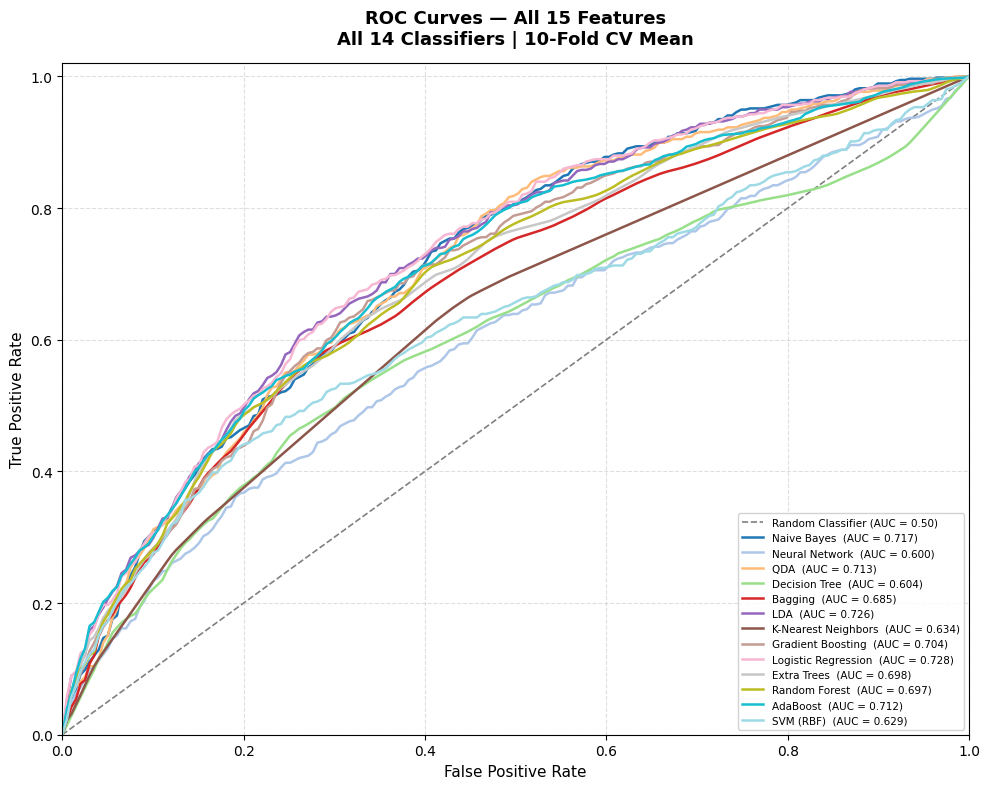

✅ Saved: roc_all_features.png


In [ ]:
#ROC curves ALL 15 Features
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

CV_SPLITS = 10

models = {
    "Naive Bayes":         GaussianNB(),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                 QuadraticDiscriminantAnalysis(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":             BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42),
    "LDA":                 LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf',    probability=True, random_state=42)
}

X_sub = X.copy().reset_index(drop=True)
y_use = y.reset_index(drop=True)

def get_mean_roc(model, X_sub, y_use, n_splits):
    tprs, aucs = [], []
    base_fpr   = np.linspace(0, 1, 200)
    cv         = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, test_idx in cv.split(X_sub, y_use):
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y_use.iloc[train_idx], y_use.iloc[test_idx]
        model.fit(X_tr, y_tr)
        y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") \
                  else model.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_te, y_score)
        aucs.append(auc(fpr, tpr))
        interp_tpr    = np.interp(base_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    return base_fpr, mean_tpr, np.mean(aucs)

colors = cm.tab20(np.linspace(0, 1, len(models)))
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.2, label='Random Classifier (AUC = 0.50)')

for (name, model), color in zip(models.items(), colors):
    print(f"  ↳ {name} ...")
    fpr, tpr, mean_auc = get_mean_roc(model, X_sub, y_use, CV_SPLITS)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{name}  (AUC = {mean_auc:.3f})")

ax.set_title(
    f"ROC Curves — All {X_sub.shape[1]} Features\n"
    f"All 14 Classifiers | {CV_SPLITS}-Fold CV Mean",
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("roc_all_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_all_features.png")

Dataset shape: (3658, 16)
Target distribution:
TenYearCHD
0    3101
1     557
Name: count, dtype: int64

Top 8 features (averaged across 5 methods):
['sysBP', 'age', 'diaBP', 'glucose', 'prevalentHyp', 'totChol', 'BMI', 'education']
  ↳ Naive Bayes ...
  ↳ Neural Network ...
  ↳ QDA ...
  ↳ Decision Tree ...
  ↳ Bagging ...
  ↳ LDA ...
  ↳ K-Nearest Neighbors ...
  ↳ Gradient Boosting ...
  ↳ Logistic Regression ...
  ↳ Extra Trees ...
  ↳ Random Forest ...
  ↳ AdaBoost ...
  ↳ SVM (RBF) ...


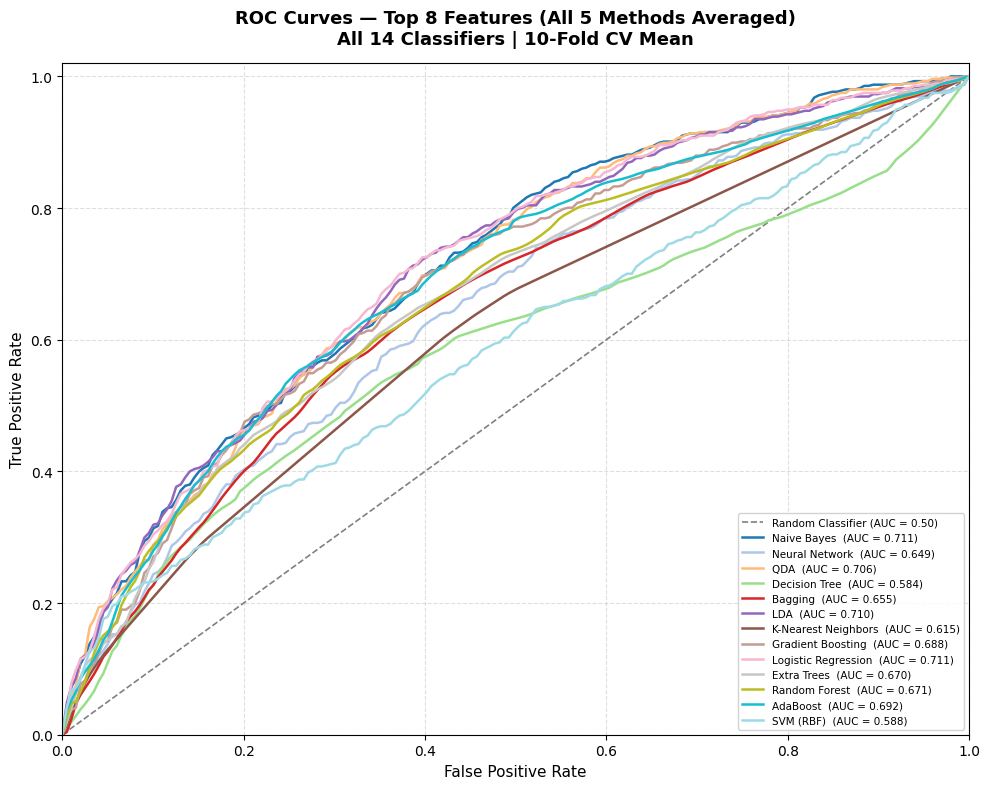

Saved: roc_top8_features.png


In [ ]:
# ==========================================================
# ROC CURVES — Top 8 Features
# All 14 Models | All 5 Methods Averaged | 10-Fold CV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier


df = pd.read_csv(INPUT_CSV)
df = df.dropna()

target_column = "TenYearCHD"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# ── Config ─────────────────────────────────────────────────
TOP_N     = 8
CV_SPLITS = 10

models = {
    "Naive Bayes":         GaussianNB(),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                 QuadraticDiscriminantAnalysis(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":             BaggingClassifier(n_estimators=50, random_state=42),
    "LDA":                 LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf',    probability=True, random_state=42)
}

# ── Feature Selection ──────────────────────────────────────
corr_scores    = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
mi_scores      = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
chi_vals, _    = chi2(abs(X), y)
chi_scores     = pd.Series(chi_vals, index=X.columns)
rf_imp         = RandomForestClassifier(n_estimators=200, random_state=42)
rf_imp.fit(X, y)
rf_importances = pd.Series(rf_imp.feature_importances_, index=X.columns)
perm           = permutation_importance(rf_imp, X, y, n_repeats=5, random_state=42)
perm_scores    = pd.Series(perm.importances_mean, index=X.columns)

METHODS = {
    "RF Importance":       rf_importances,
    "Pearson Correlation": corr_scores,
    "Mutual Information":  mi_scores,
    "Chi-Square":          chi_scores,
    "Permutation":         perm_scores,
}


norm_scores = {}
for method_name, scores in METHODS.items():
    s     = scores - scores.min()
    denom = s.max()
    norm_scores[method_name] = s / denom if denom > 0 else s

avg_score    = pd.DataFrame(norm_scores).mean(axis=1)
top_features = avg_score.sort_values(ascending=False).head(TOP_N).index.tolist()
X_sub        = X[top_features]

print(f"\nTop {TOP_N} features (averaged across 5 methods):")
print(top_features)

# ── ROC helper ─────────────────────────────────────────────
def get_mean_roc(model, X_sub, y, n_splits):
    tprs     = []
    aucs     = []
    base_fpr = np.linspace(0, 1, 200)
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, test_idx in cv.split(X_sub, y):
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx],     y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") \
                  else model.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_te, y_score)
        aucs.append(auc(fpr, tpr))
        interp_tpr    = np.interp(base_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    return base_fpr, mean_tpr, np.mean(aucs)

# ── Plot ───────────────────────────────────────────────────
colors = cm.tab20(np.linspace(0, 1, len(models)))
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.2, label='Random Classifier (AUC = 0.50)')

for (name, model), color in zip(models.items(), colors):
    print(f"  ↳ {name} ...")
    fpr, tpr, mean_auc = get_mean_roc(model, X_sub, y, CV_SPLITS)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{name}  (AUC = {mean_auc:.3f})")

ax.set_title(
    f"ROC Curves — Top {TOP_N} Features (All 5 Methods Averaged)\n"
    f"All 14 Classifiers | {CV_SPLITS}-Fold CV Mean",
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fname = f"roc_top{TOP_N}_features.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

Top 10 features (averaged across 5 methods):
['sysBP', 'age', 'diaBP', 'glucose', 'prevalentHyp', 'totChol', 'BMI', 'education', 'cigsPerDay', 'heartRate']
  ↳ Naive Bayes ...
  ↳ Neural Network ...
  ↳ QDA ...
  ↳ Decision Tree ...
  ↳ Bagging ...
  ↳ LDA ...
  ↳ K-Nearest Neighbors ...
  ↳ Gradient Boosting ...
  ↳ Logistic Regression ...
  ↳ Extra Trees ...
  ↳ Random Forest ...
  ↳ AdaBoost ...
  ↳ SVM (RBF) ...


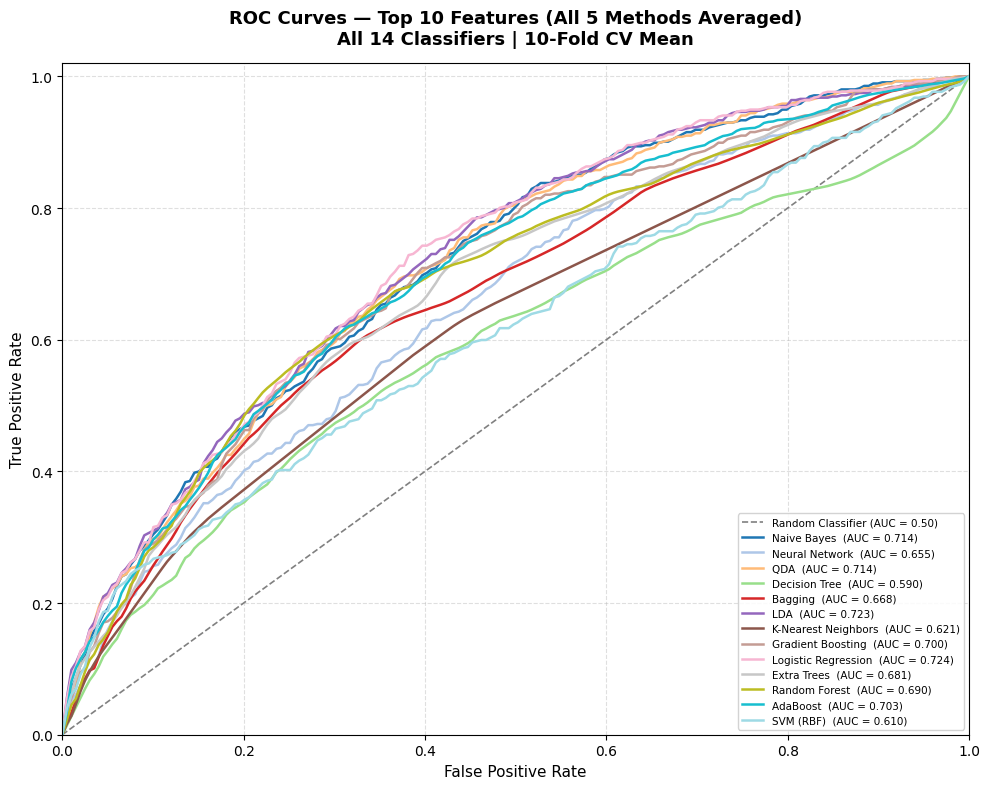

✅ Saved: roc_top10_features.png


In [ ]:

# ROC CURVES — Top 10 Features
# All 14 Models | All 5 Methods Averaged | 10-Fold CV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

TOP_N      = 10
CV_SPLITS  = 10

models = {
    "Naive Bayes":         GaussianNB(),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                 QuadraticDiscriminantAnalysis(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":             BaggingClassifier(n_estimators=50, random_state=42),
    "LDA":                 LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf',    probability=True, random_state=42)
}

# ── Feature Selection ──────────────────────────────────────
corr_scores    = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
mi_scores      = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
chi_vals, _    = chi2(abs(X), y)
chi_scores     = pd.Series(chi_vals, index=X.columns)
rf_imp         = RandomForestClassifier(n_estimators=200, random_state=42)
rf_imp.fit(X, y)
rf_importances = pd.Series(rf_imp.feature_importances_, index=X.columns)
perm           = permutation_importance(rf_imp, X, y, n_repeats=5, random_state=42)
perm_scores    = pd.Series(perm.importances_mean, index=X.columns)

METHODS = {
    "RF Importance":       rf_importances,
    "Pearson Correlation": corr_scores,
    "Mutual Information":  mi_scores,
    "Chi-Square":          chi_scores,
    "Permutation":         perm_scores,
}

# ── Average features across all 5 methods ─────────────────
norm_scores = {}
for method_name, scores in METHODS.items():
    s     = scores - scores.min()
    denom = s.max()
    norm_scores[method_name] = s / denom if denom > 0 else s

avg_score    = pd.DataFrame(norm_scores).mean(axis=1)
top_features = avg_score.sort_values(ascending=False).head(TOP_N).index.tolist()
X_sub        = X[top_features]

print(f"Top {TOP_N} features (averaged across 5 methods):")
print(top_features)

# ── ROC helper ─────────────────────────────────────────────
def get_mean_roc(model, X_sub, y, n_splits):
    tprs     = []
    aucs     = []
    base_fpr = np.linspace(0, 1, 200)
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, test_idx in cv.split(X_sub, y):
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx],     y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") \
                  else model.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_te, y_score)
        aucs.append(auc(fpr, tpr))
        interp_tpr    = np.interp(base_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    return base_fpr, mean_tpr, np.mean(aucs)

# ── Plot ───────────────────────────────────────────────────
colors = cm.tab20(np.linspace(0, 1, len(models)))
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.2, label='Random Classifier (AUC = 0.50)')

for (name, model), color in zip(models.items(), colors):
    print(f"  ↳ {name} ...")
    fpr, tpr, mean_auc = get_mean_roc(model, X_sub, y, CV_SPLITS)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{name}  (AUC = {mean_auc:.3f})")

ax.set_title(
    f"ROC Curves — Top {TOP_N} Features (All 5 Methods Averaged)\n"
    f"All 14 Classifiers | {CV_SPLITS}-Fold CV Mean",
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fname = f"roc_top{TOP_N}_features.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fname}")

Top 12 features (averaged across 5 methods):
['sysBP', 'age', 'diaBP', 'glucose', 'prevalentHyp', 'totChol', 'BMI', 'education', 'cigsPerDay', 'heartRate', 'sex', 'diabetes']
  ↳ Naive Bayes ...
  ↳ Neural Network ...
  ↳ QDA ...
  ↳ Decision Tree ...
  ↳ Bagging ...
  ↳ LDA ...
  ↳ K-Nearest Neighbors ...
  ↳ Gradient Boosting ...
  ↳ Logistic Regression ...
  ↳ Extra Trees ...
  ↳ Random Forest ...
  ↳ AdaBoost ...
  ↳ SVM (RBF) ...


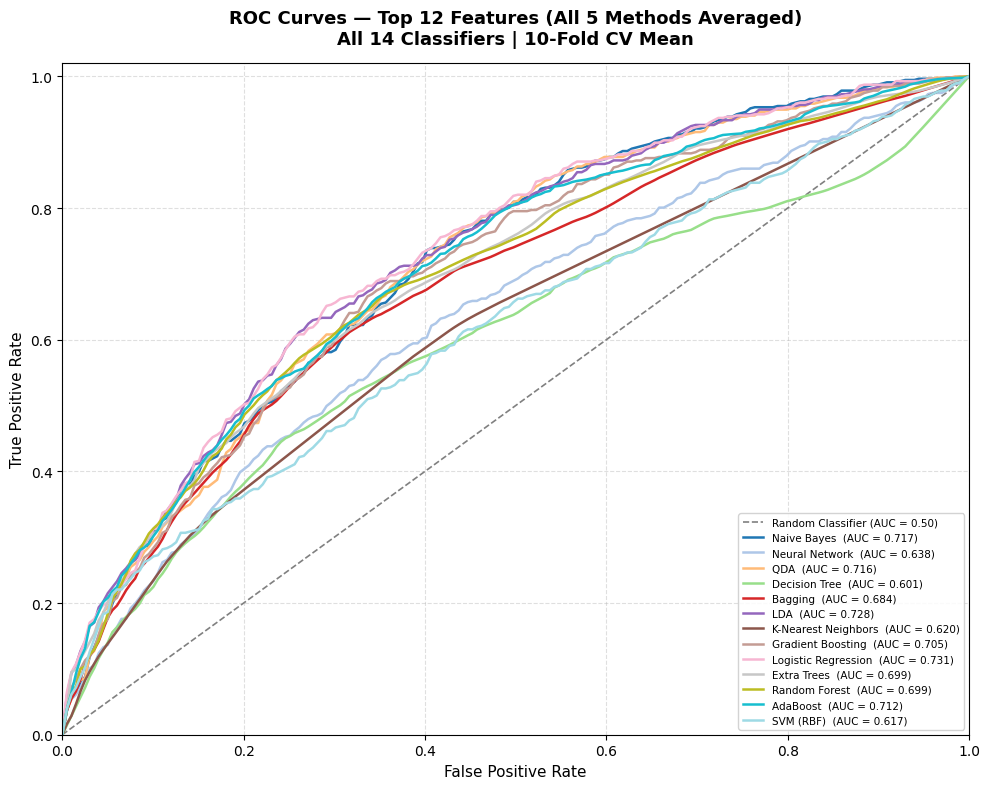

✅ Saved: roc_top12_features.png


In [ ]:

# ROC CURVES — Top 12 Features
# All 14 Models | All 5 Methods Averaged | 10-Fold CV


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

TOP_N      = 12
CV_SPLITS  = 10

models = {
    "Naive Bayes":         GaussianNB(),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                 QuadraticDiscriminantAnalysis(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":             BaggingClassifier(n_estimators=50, random_state=42),
    "LDA":                 LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf',    probability=True, random_state=42)
}


corr_scores    = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
mi_scores      = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
chi_vals, _    = chi2(abs(X), y)
chi_scores     = pd.Series(chi_vals, index=X.columns)
rf_imp         = RandomForestClassifier(n_estimators=200, random_state=42)
rf_imp.fit(X, y)
rf_importances = pd.Series(rf_imp.feature_importances_, index=X.columns)
perm           = permutation_importance(rf_imp, X, y, n_repeats=5, random_state=42)
perm_scores    = pd.Series(perm.importances_mean, index=X.columns)

METHODS = {
    "RF Importance":       rf_importances,
    "Pearson Correlation": corr_scores,
    "Mutual Information":  mi_scores,
    "Chi-Square":          chi_scores,
    "Permutation":         perm_scores,
}

# ── Average features across all 5 methods ─────────────────
norm_scores = {}
for method_name, scores in METHODS.items():
    s     = scores - scores.min()
    denom = s.max()
    norm_scores[method_name] = s / denom if denom > 0 else s

avg_score    = pd.DataFrame(norm_scores).mean(axis=1)
top_features = avg_score.sort_values(ascending=False).head(TOP_N).index.tolist()
X_sub        = X[top_features]

print(f"Top {TOP_N} features (averaged across 5 methods):")
print(top_features)

# ── ROC helper ─────────────────────────────────────────────
def get_mean_roc(model, X_sub, y, n_splits):
    tprs     = []
    aucs     = []
    base_fpr = np.linspace(0, 1, 200)
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, test_idx in cv.split(X_sub, y):
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx],     y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") \
                  else model.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_te, y_score)
        aucs.append(auc(fpr, tpr))
        interp_tpr    = np.interp(base_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    return base_fpr, mean_tpr, np.mean(aucs)


colors = cm.tab20(np.linspace(0, 1, len(models)))
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.2, label='Random Classifier (AUC = 0.50)')

for (name, model), color in zip(models.items(), colors):
    print(f"  ↳ {name} ...")
    fpr, tpr, mean_auc = get_mean_roc(model, X_sub, y, CV_SPLITS)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{name}  (AUC = {mean_auc:.3f})")

ax.set_title(
    f"ROC Curves — Top {TOP_N} Features (All 5 Methods Averaged)\n"
    f"All 14 Classifiers | {CV_SPLITS}-Fold CV Mean",
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fname = f"roc_top{TOP_N}_features.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fname}")

In [ ]:
# ==========================================================
# HYPERPARAMETER TUNING — Top 8 Features
# All 14 Models | GridSearchCV + RandomizedSearchCV
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


TOP_N        = 8
CV_SPLITS    = 10
N_ITER       = 20
SCORING      = make_scorer(f1_score)
OUTPUT_XLS   = f"hyperparameter_results_top{TOP_N}.xlsx"

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

corr_scores    = X.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
mi_scores      = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
chi_vals, _    = chi2(abs(X), y)
chi_scores     = pd.Series(chi_vals, index=X.columns)
rf_imp         = RandomForestClassifier(n_estimators=200, random_state=42)
rf_imp.fit(X, y)
rf_importances = pd.Series(rf_imp.feature_importances_, index=X.columns)
perm           = permutation_importance(rf_imp, X, y, n_repeats=5, random_state=42)
perm_scores    = pd.Series(perm.importances_mean, index=X.columns)

METHODS = {
    "RF Importance":       rf_importances,
    "Pearson Correlation": corr_scores,
    "Mutual Information":  mi_scores,
    "Chi-Square":          chi_scores,
    "Permutation":         perm_scores,
}

norm_scores = {}
for method_name, scores in METHODS.items():
    s     = scores - scores.min()
    denom = s.max()
    norm_scores[method_name] = s / denom if denom > 0 else s

avg_score    = pd.DataFrame(norm_scores).mean(axis=1)
top_features = avg_score.sort_values(ascending=False).head(TOP_N).index.tolist()
X_sub        = X[top_features]

print(f"Top {TOP_N} features: {top_features}")

# ==========================================================
# PARAM GRIDS
# ==========================================================
grid_params = {
    "Logistic Regression": {
        "C":        [0.01, 0.1, 1, 10, 100],
        "solver":   ["lbfgs", "liblinear"],
        "penalty":  ["l2"],
        "max_iter": [1000],
    },
    "Decision Tree": {
        "max_depth":         [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
        "criterion":         ["gini", "entropy"],
    },
    "Random Forest": {
        "n_estimators":      [50, 100, 200],
        "max_depth":         [5, 10, None],
        "min_samples_split": [2, 5],
        "max_features":      ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators":  [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth":     [3, 5, 7],
        "subsample":     [0.8, 1.0],
    },
    "AdaBoost": {
        "n_estimators":  [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.5, 1.0],
    },
    "Extra Trees": {
        "n_estimators":      [50, 100, 200],
        "max_depth":         [5, 10, None],
        "min_samples_split": [2, 5],
        "max_features":      ["sqrt", "log2"],
    },
    "Bagging": {
        "n_estimators": [10, 50, 100],
        "max_samples":  [0.5, 0.7, 1.0],
        "max_features": [0.5, 0.7, 1.0],
    },
    "SVM (RBF)": {
        "C":     [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01, 0.001],
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights":     ["uniform", "distance"],
        "metric":      ["euclidean", "manhattan"],
    },
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    },
    "LDA": {
        "solver":    ["svd", "lsqr"],
        "shrinkage": [None, "auto"],
    },
    "QDA": {
        "reg_param": [0.0, 0.1, 0.3, 0.5],
    },
    "Neural Network": {
        "hidden_layer_sizes": [(50,), (100,), (100, 50), (128, 64)],
        "activation":         ["relu", "tanh"],
        "alpha":              [0.0001, 0.001, 0.01],
        "learning_rate":      ["constant", "adaptive"],
    },
}

random_params = {
    "Logistic Regression": {
        "C":        loguniform(0.001, 100),
        "solver":   ["lbfgs", "liblinear"],
        "penalty":  ["l2"],
        "max_iter": [1000],
    },
    "Decision Tree": {
        "max_depth":         randint(2, 20),
        "min_samples_split": randint(2, 20),
        "min_samples_leaf":  randint(1, 10),
        "criterion":         ["gini", "entropy"],
    },
    "Random Forest": {
        "n_estimators":      randint(50, 300),
        "max_depth":         [5, 10, 15, None],
        "min_samples_split": randint(2, 10),
        "max_features":      ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators":  randint(50, 300),
        "learning_rate": loguniform(0.01, 0.5),
        "max_depth":     randint(2, 10),
        "subsample":     uniform(0.6, 0.4),
    },
    "AdaBoost": {
        "n_estimators":  randint(50, 300),
        "learning_rate": loguniform(0.01, 1.0),
    },
    "Extra Trees": {
        "n_estimators":      randint(50, 300),
        "max_depth":         [5, 10, 15, None],
        "min_samples_split": randint(2, 10),
        "max_features":      ["sqrt", "log2"],
    },
    "Bagging": {
        "n_estimators": randint(10, 150),
        "max_samples":  uniform(0.5, 0.5),
        "max_features": uniform(0.5, 0.5),
    },
    "SVM (RBF)": {
        "C":     loguniform(0.01, 100),
        "gamma": loguniform(0.001, 1.0),
    },
    "SVM (Linear)": {
        "C": loguniform(0.001, 100),
    },
    "K-Nearest Neighbors": {
        "n_neighbors": randint(2, 20),
        "weights":     ["uniform", "distance"],
        "metric":      ["euclidean", "manhattan", "minkowski"],
    },
    "Naive Bayes": {
        "var_smoothing": loguniform(1e-10, 1e-4),
    },
    "LDA": {
        "solver":    ["svd", "lsqr"],
        "shrinkage": [None, "auto", 0.1, 0.3, 0.5],
    },
    "QDA": {
        "reg_param": uniform(0.0, 0.5),
    },
    "Neural Network": {
        "hidden_layer_sizes": [(50,), (100,), (100, 50), (128, 64), (64, 32)],
        "activation":         ["relu", "tanh"],
        "alpha":              loguniform(1e-5, 0.1),
        "learning_rate":      ["constant", "adaptive"],
        "max_iter":           [500],
    },
}


base_models = {
    "Logistic Regression":  LogisticRegression(random_state=42),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
    "AdaBoost":             AdaBoostClassifier(random_state=42),
    "Extra Trees":          ExtraTreesClassifier(random_state=42),
    "Bagging":              BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    "SVM (RBF)":            SVC(kernel='rbf',    probability=True, random_state=42),
    "K-Nearest Neighbors":  KNeighborsClassifier(),
    "Naive Bayes":          GaussianNB(),
    "LDA":                  LinearDiscriminantAnalysis(),
    "QDA":                  QuadraticDiscriminantAnalysis(),
    "Neural Network":       MLPClassifier(random_state=42),
}


results = []

for name, model in base_models.items():
    print(f"\n{'='*60}\nTuning: {name}\n{'='*60}")

    print("  → GridSearchCV ...")
    grid = GridSearchCV(
        estimator=model, param_grid=grid_params[name],
        scoring=SCORING, cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    grid.fit(X_sub, y)
    grid_best_score  = round(grid.best_score_, 4)
    grid_best_params = grid.best_params_
    print(f"     Best F1 : {grid_best_score} | Params: {grid_best_params}")

    print("  → RandomizedSearchCV ...")
    rand = RandomizedSearchCV(
        estimator=model, param_distributions=random_params[name],
        n_iter=N_ITER, scoring=SCORING, cv=cv,
        n_jobs=-1, refit=True, random_state=42, verbose=0
    )
    rand.fit(X_sub, y)
    rand_best_score  = round(rand.best_score_, 4)
    rand_best_params = rand.best_params_
    print(f"     Best F1 : {rand_best_score} | Params: {rand_best_params}")

    if grid_best_score >= rand_best_score:
        best_method, best_score, best_params = "GridSearch", grid_best_score, grid_best_params
    else:
        best_method, best_score, best_params = "RandomizedSearch", rand_best_score, rand_best_params

    print(f"  ✅ Winner : {best_method}  |  F1 = {best_score}")

    results.append({
        "Model":                  name,
        "Grid_Best_F1":           grid_best_score,
        "Grid_Best_Params":       str(grid_best_params),
        "Randomized_Best_F1":     rand_best_score,
        "Randomized_Best_Params": str(rand_best_params),
        "Overall_Best_Method":    best_method,
        "Overall_Best_F1":        best_score,
        "Overall_Best_Params":    str(best_params),
    })


df_results = pd.DataFrame(results).sort_values(
    "Overall_Best_F1", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(f"TUNING SUMMARY — Top {TOP_N} Features")
print("="*80)
print(df_results[["Model", "Grid_Best_F1", "Randomized_Best_F1",
                  "Overall_Best_Method", "Overall_Best_F1"]].to_string(index=False))

# ==========================================================
# EXCEL EXPORT
# ==========================================================
HEADER_FILL = PatternFill("solid", start_color="1F4E79")
BEST_FILL   = PatternFill("solid", start_color="E2EFDA")
ALT_FILL    = PatternFill("solid", start_color="D6E4F0")
WHITE_BOLD  = Font(name="Arial", bold=True, color="FFFFFF", size=11)
BEST_FONT   = Font(name="Arial", bold=True, color="375623", size=10)
NORMAL_FONT = Font(name="Arial", size=10)
CENTER      = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT        = Alignment(horizontal="left",   vertical="center", wrap_text=True)
thin        = Side(style="thin", color="BFBFBF")
THIN_BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = Workbook()
ws = wb.active
ws.title = f"Top {TOP_N} Tuning Results"

ws.merge_cells("A1:H1")
t       = ws["A1"]
t.value = f"Hyperparameter Tuning — Top {TOP_N} Features | All 14 Models | {CV_SPLITS}-Fold CV"
t.font  = Font(name="Arial", bold=True, size=14, color="FFFFFF")
t.fill  = HEADER_FILL
t.alignment = CENTER
ws.row_dimensions[1].height = 32

headers = [
    "Model", "Grid Best F1", "Grid Best Params",
    "Randomized Best F1", "Randomized Best Params",
    "Overall Best Method", "Overall Best F1", "Overall Best Params"
]
for ci, h in enumerate(headers, 1):
    cell = ws.cell(row=2, column=ci, value=h)
    cell.font, cell.fill = WHITE_BOLD, HEADER_FILL
    cell.alignment, cell.border = CENTER, THIN_BORDER

top3 = set(df_results.head(3)["Model"].tolist())
for ri, row_data in df_results.iterrows():
    is_top = row_data["Model"] in top3
    fill   = BEST_FILL if is_top else (ALT_FILL if ri % 2 == 1 else PatternFill())
    font   = BEST_FONT if is_top else NORMAL_FONT
    vals   = [
        row_data["Model"], row_data["Grid_Best_F1"], row_data["Grid_Best_Params"],
        row_data["Randomized_Best_F1"], row_data["Randomized_Best_Params"],
        row_data["Overall_Best_Method"], row_data["Overall_Best_F1"], row_data["Overall_Best_Params"],
    ]
    for ci, val in enumerate(vals, 1):
        cell = ws.cell(row=ri + 3, column=ci, value=val)
        cell.fill, cell.font = fill, font
        cell.alignment = CENTER if ci != 1 else LEFT
        cell.border = THIN_BORDER

for col, w in {"A": 22, "B": 14, "C": 45, "D": 18, "E": 45, "F": 20, "G": 16, "H": 45}.items():
    ws.column_dimensions[col].width = w

wb.save(OUTPUT_XLS)
print(f"\n✅ Saved: {OUTPUT_XLS}")

from google.colab import files
files.download(OUTPUT_XLS)

Top 8 features: ['sysBP', 'age', 'diaBP', 'glucose', 'prevalentHyp', 'totChol', 'BMI', 'education']

Tuning: Logistic Regression
  → GridSearchCV ...
     Best F1 : 0.0787 | Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  → RandomizedSearchCV ...
     Best F1 : 0.0787 | Params: {'C': np.float64(0.0745934328572655), 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  ✅ Winner : GridSearch  |  F1 = 0.0787

Tuning: Decision Tree
  → GridSearchCV ...
     Best F1 : 0.2402 | Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
  → RandomizedSearchCV ...
     Best F1 : 0.2121 | Params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
  ✅ Winner : GridSearch  |  F1 = 0.2402

Tuning: Random Forest
  → GridSearchCV ...
     Best F1 : 0.107 | Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 50}
  → RandomizedSearchCV ...
     Best F1 : 0.109

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

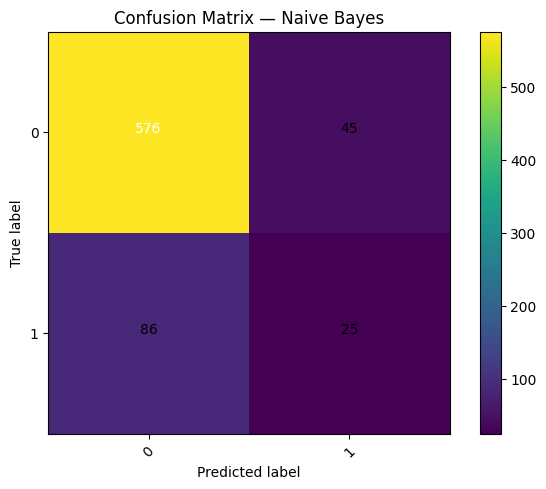

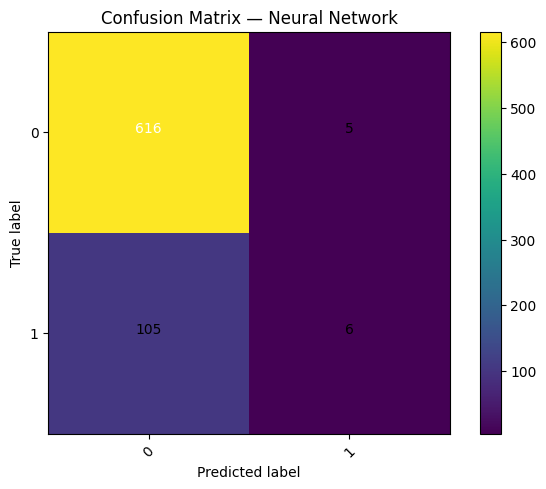

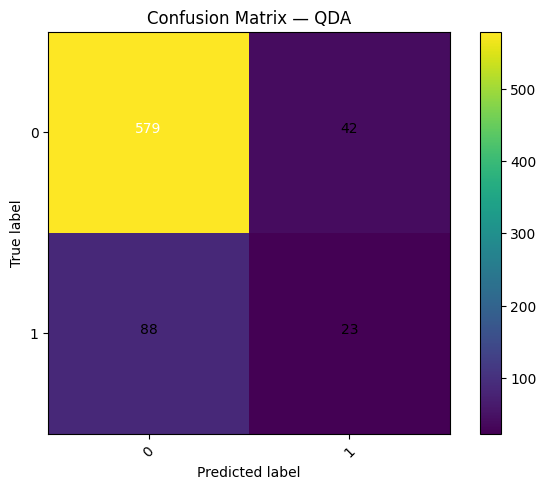

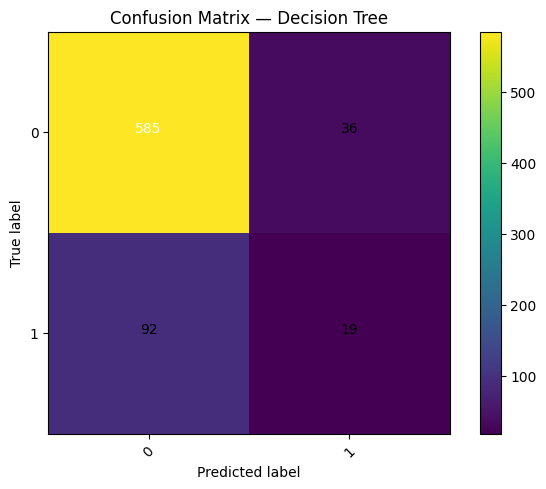

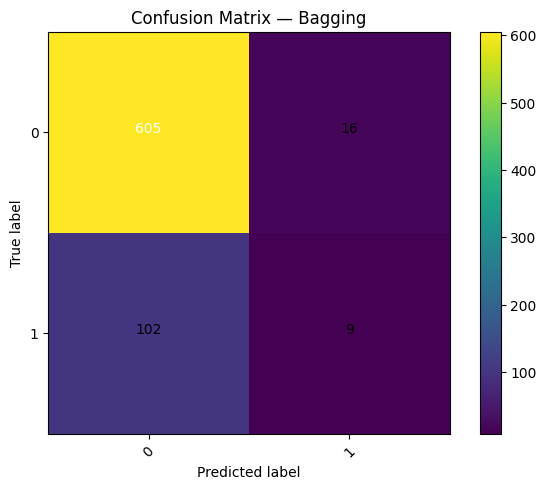

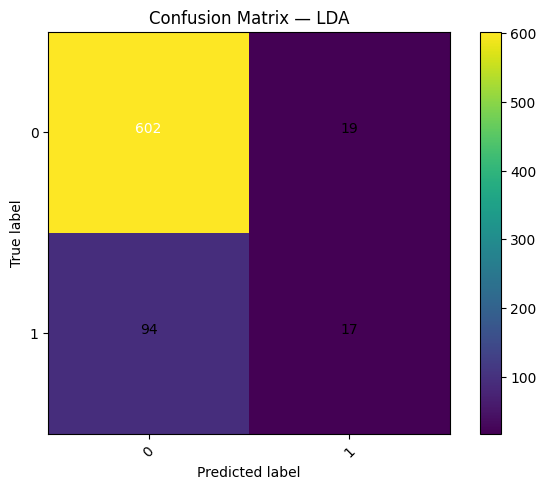

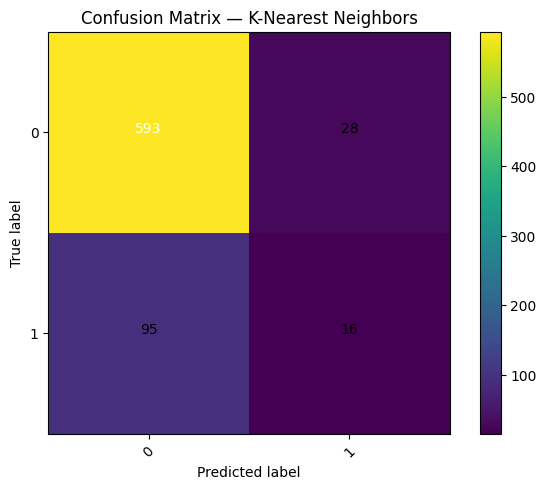

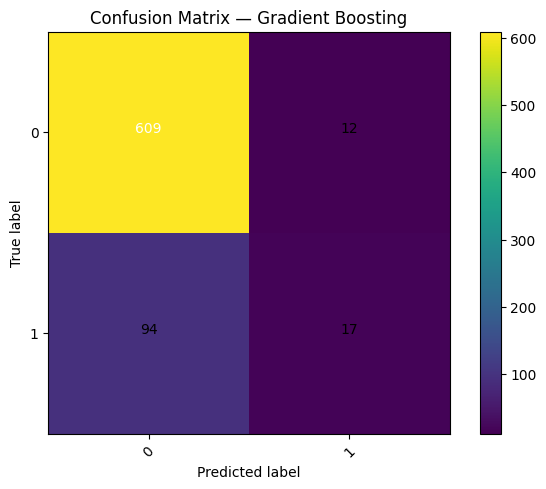

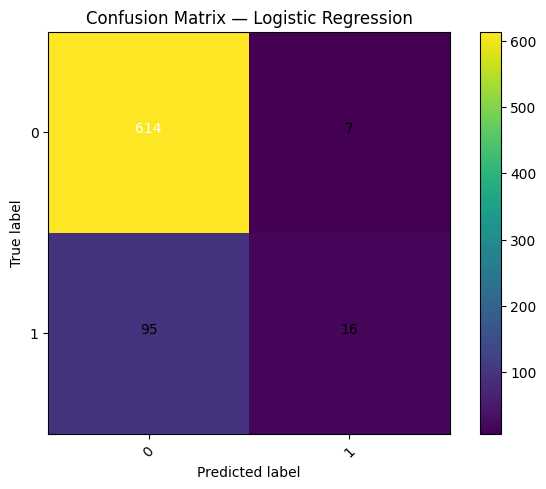

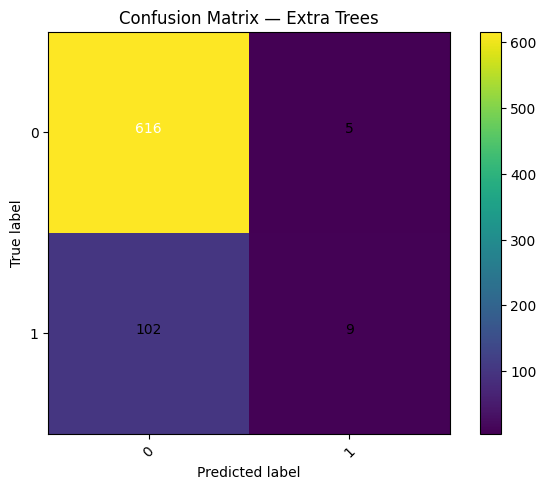

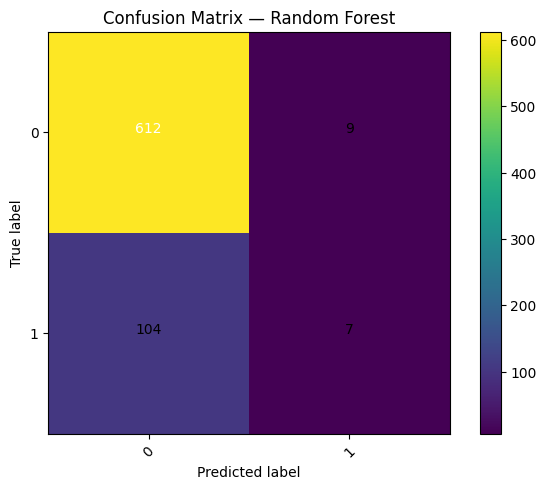

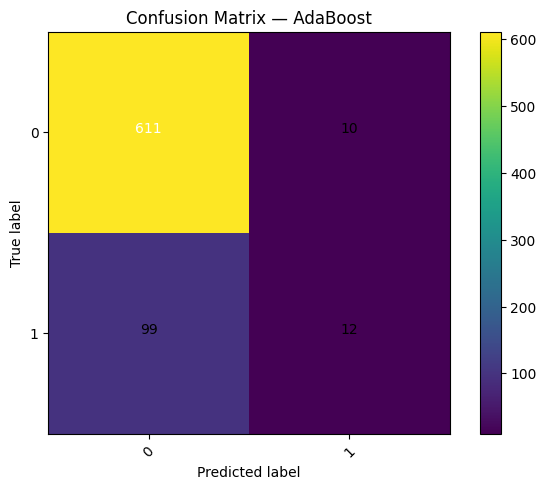

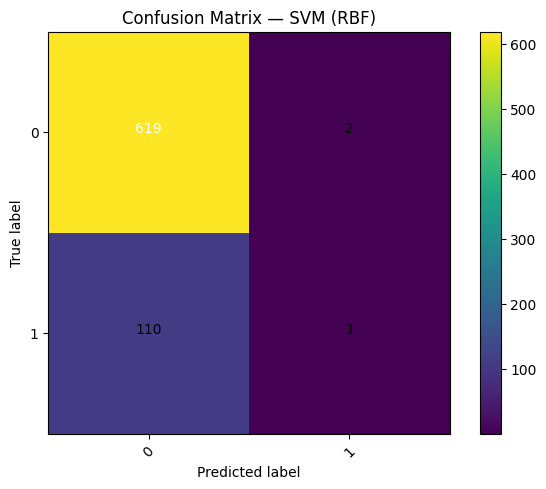

In [ ]:
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

models = {
    "Naive Bayes":          GaussianNB(),
    "Neural Network":       MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "QDA":                  QuadraticDiscriminantAnalysis(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=10, random_state=42),
    "Bagging":              BaggingClassifier(n_estimators=50, random_state=42),
    "LDA":                  LinearDiscriminantAnalysis(),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":             AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":            SVC(kernel='rbf', random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y
)

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

def plot_confusion(cm, classes, title='Confusion matrix'):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

classes = [str(c) for c in np.unique(y_test)]
for name, est in fitted_models.items():
    y_pred = est.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion(cm, classes, title=f"Confusion Matrix — {name}")

Auto-detected CSV: results_chi2.csv
Loaded: (13, 5)
Using target: F1-Score
Target sample: 0    0.804025
1    0.801262
2    0.799531
3    0.798315
4    0.796408
5    0.795702
6    0.795619
7    0.794797
Name: F1-Score, dtype: float64
Target unique count: 13
Dropping Model (non-numeric).
Final X shape: (13, 3)
qcut unique bins: 3
Using classification with 3 bins. Class counts:
 0    5
2    4
1    4
Name: count, dtype: int64
Train/test shapes: (10, 3) (3, 3)
=== Running classification comparison ===
Saved classification metrics CSV.
Saved chart to: /mnt/data/auto_compare_outputs/classification_comparison.png


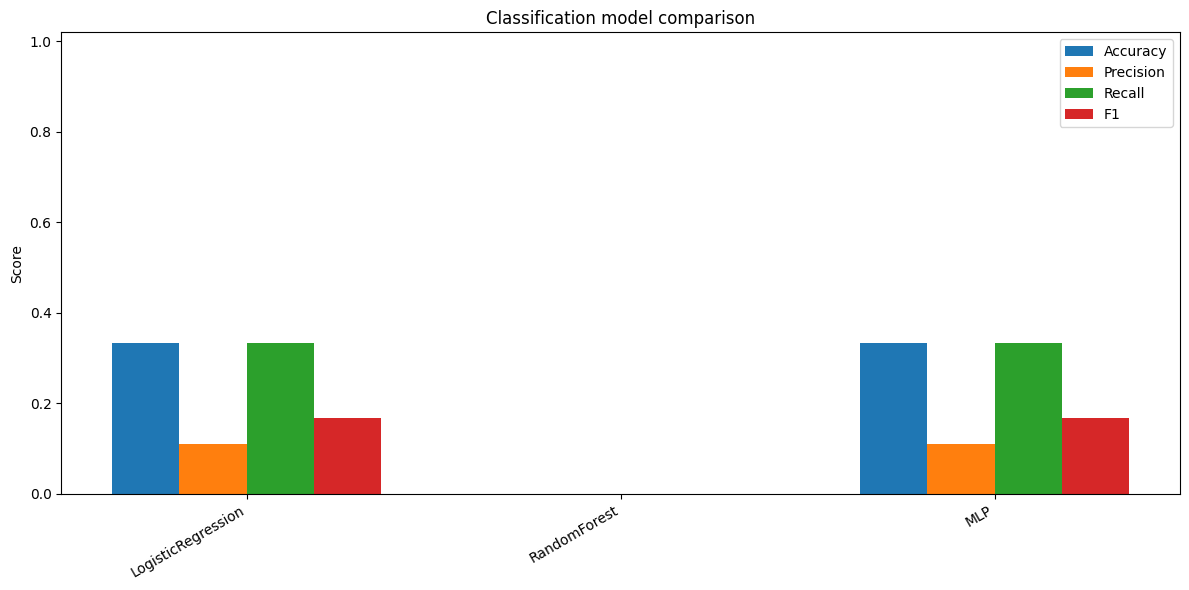

All done. Outputs are in: /mnt/data/auto_compare_outputs


In [ ]:

import pandas as pd
import numpy as np
import glob, os, traceback
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt

# Auto-detect CSV
cand = glob.glob('/mnt/data/*.csv') + glob.glob('*.csv') + glob.glob('/content/*.csv')
if len(cand) > 0:
    INPUT_CSV = cand[0]
    print("Auto-detected CSV:", INPUT_CSV)
else:
    raise FileNotFoundError("Upload a CSV and set INPUT_CSV.")

df = pd.read_csv(INPUT_CSV)
print("Loaded:", df.shape)

# detect target
target_candidates = ['target','heart_disease','HeartDisease','hd','diagnosis','label','output']
target_col = None
for c in df.columns:
    if c.lower() in [t.lower() for t in target_candidates]:
        target_col = c
        break
if target_col is None:
    target_col = df.columns[-1]
print("Using target:", target_col)
print("Target sample:", df[target_col].head(8))
print("Target unique count:", df[target_col].nunique())

# Minimal feature handling (convert numeric-like, drop heavy text)
X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

# drop NaN target rows
if y_raw.isna().any():
    mask = ~y_raw.isna()
    X = X.loc[mask].reset_index(drop=True)
    y_raw = y_raw.loc[mask].reset_index(drop=True)

cols_to_drop = []
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        conv = pd.to_numeric(X[col], errors='coerce')
        non_na_frac = conv.notna().mean()
        if non_na_frac >= 0.75:
            X[col] = conv
            print(f"Converted {col} -> numeric (kept).")
        else:
            cols_to_drop.append(col)
            print(f"Dropping {col} (non-numeric).")
if cols_to_drop:
    X = X.drop(columns=cols_to_drop)

# drop rows with any NaN in features
na_rows = X.isna().any(axis=1).sum()
if na_rows > 0:
    print(f"Dropping {na_rows} rows with NaN in features.")
    mask = ~X.isna().any(axis=1)
    X = X.loc[mask].reset_index(drop=True)
    y_raw = y_raw.loc[mask].reset_index(drop=True)

print("Final X shape:", X.shape)


def try_qcut(y_series, q=3):
    try:

        binned = pd.qcut(y_series, q=q, labels=False, duplicates='drop')
        uniq = binned.nunique(dropna=True)
        return binned, uniq
    except Exception as e:
        print("qcut failed:", e)
        return None, 0

binned, uniq = try_qcut(y_raw, q=3)
print("qcut unique bins:", uniq)

use_classification = False
y_for_model = None
if uniq >= 2:

    use_classification = True
    y_for_model = binned.astype(int).values
    print("Using classification with", uniq, "bins. Class counts:\n", pd.Series(y_for_model).value_counts())
else:

    print("qcut gave <2 bins. Trying median binarization.")
    thresh = y_raw.median()
    y_bin = (y_raw > thresh).astype(int)
    if y_bin.nunique() >= 2:
        use_classification = True
        y_for_model = y_bin.values
        print("Using binary classification by median. Class counts:\n", pd.Series(y_for_model).value_counts())
    else:
        print("Median binarization also failed (single class). Will fallback to regression.")
        use_classification = False
        y_for_model = y_raw.values.astype(float)

# Final safety check
if use_classification and len(np.unique(y_for_model)) < 2:
    print("After conversions still <2 classes -> fallback to regression.")
    use_classification = False
    y_for_model = y_raw.values.astype(float)

# Train/test split (safe stratify)
stratify_arg = None
if use_classification:
    vc = pd.Series(y_for_model).value_counts()
    if (vc < 2).any():
        print("Some classes <2 samples -> skipping stratify.")
    else:
        stratify_arg = y_for_model

X_train, X_test, y_train, y_test = train_test_split(X, y_for_model, test_size=0.2, random_state=42, stratify=stratify_arg)
print("Train/test shapes:", X_train.shape, X_test.shape)

out_dir = "/mnt/data/auto_compare_outputs"
os.makedirs(out_dir, exist_ok=True)

if use_classification:
    print("=== Running classification comparison ===")
    classifiers = {
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
    }
    results = []
    for name, clf in classifiers.items():
        try:
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
            rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
            # save model
            joblib.dump(clf, os.path.join(out_dir, f"model_{name}.joblib"))
        except Exception as e:
            print(f"{name} failed:", e)
            results.append({"model": name, "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan})
    res_df = pd.DataFrame(results).set_index('model')
    res_df.to_csv(os.path.join(out_dir, "classification_metrics.csv"))
    print("Saved classification metrics CSV.")


    metrics = ['accuracy', 'precision', 'recall', 'f1']
    n = len(res_df)
    x = np.arange(n)
    width = 0.18
    plt.figure(figsize=(12,6))
    for i, m in enumerate(metrics):
        vals = res_df[m].values
        plt.bar(x + (i-1.5)*width, vals, width=width, label=m.capitalize())
    plt.xticks(x, res_df.index, rotation=30, ha='right')
    plt.ylim(0,1.02)
    plt.title("Classification model comparison")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    chart_path = os.path.join(out_dir, "classification_comparison.png")
    plt.savefig(chart_path, dpi=150)
    print("Saved chart to:", chart_path)
    plt.show()

else:
    print("=== Running regression comparison (fallback) ===")
    regressors = {
        "RandomForestReg": RandomForestRegressor(n_estimators=200, random_state=42),
        "MLPReg": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
    }
    results = []
    for name, reg in regressors.items():
        try:
            reg.fit(X_train, y_train)
            y_pred = reg.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            rmse = mean_squared_error(y_test, y_pred, squared=False)
            mae = mean_absolute_error(y_test, y_pred)
            results.append({"model": name, "r2": r2, "rmse": rmse, "mae": mae})
            joblib.dump(reg, os.path.join(out_dir, f"reg_{name}.joblib"))
        except Exception as e:
            print(f"{name} failed:", e)
            results.append({"model": name, "r2": np.nan, "rmse": np.nan, "mae": np.nan})
    res_df = pd.DataFrame(results).set_index('model')
    res_df.to_csv(os.path.join(out_dir, "regression_metrics.csv"))
    print("Saved regression metrics CSV.")


    r2_vals = res_df['r2'].fillna(-1).values
    rmse_vals = res_df['rmse'].fillna(np.nan).values
    rmse_score = np.array([1/(1+v) if not np.isnan(v) else 0 for v in rmse_vals])

    models = res_df.index.tolist()
    x = np.arange(len(models))
    width = 0.35
    plt.figure(figsize=(10,6))
    plt.bar(x - width/2, r2_vals, width=width, label='R2 (higher better)')
    plt.bar(x + width/2, rmse_score, width=width, label='1/(1+RMSE) (higher better)')
    plt.xticks(x, models, rotation=30, ha='right')
    plt.title("Regression comparison (R2 and transformed RMSE)")
    plt.legend()
    plt.tight_layout()
    chart_path = os.path.join(out_dir, "regression_comparison.png")
    plt.savefig(chart_path, dpi=150)
    print("Saved chart to:", chart_path)
    plt.show()

print("All done. Outputs are in:", out_dir)


In [ ]:
import os
import pandas as pd
import numpy as np

print("\n===============================")
print("Saving final prediction results")
print("===============================\n")


if 'f1' not in res_df.columns and use_classification:
    raise KeyError("res_df must contain an 'f1' column for classification best-model selection. "
                   f"Available columns: {list(res_df.columns)}")

if not use_classification and 'rmse' not in res_df.columns:
    raise KeyError("res_df must contain an 'rmse' column for regression best-model selection. "
                   f"Available columns: {list(res_df.columns)}")


if use_classification:
    metric_col = 'f1'

    best_row_label = res_df[metric_col].astype(float).idxmax()
    # numeric position:
    best_pos = res_df[metric_col].astype(float).values.argmax()
else:
    metric_col = 'rmse'
    best_row_label = res_df[metric_col].astype(float).idxmin()
    best_pos = res_df[metric_col].astype(float).values.argmin()


candidate_name_cols = ['model', 'Model', 'estimator', 'name', 'classifier']
model_name_col = next((c for c in candidate_name_cols if c in res_df.columns), None)


model_name = None
if model_name_col is not None:

    try:
        model_name = res_df.at[best_row_label, model_name_col]
    except Exception:

        model_name = res_df.iloc[best_pos][model_name_col]
else:

    idx_val = res_df.index[best_pos]
    if isinstance(idx_val, str):
        model_name = idx_val
    else:

        for alt in ['estimator', 'Model', 'name', 'classifier']:
            if alt in res_df.columns:
                model_name = res_df.iloc[best_pos][alt]
                break


if model_name is None:
    print("Could not determine the model name from res_df.")
    print("res_df columns:", list(res_df.columns))
    print("res_df index (first 10):", list(res_df.index[:10]))

    if isinstance(classifiers, dict):
        print("classifiers keys:", list(classifiers.keys())[:20])
    else:
        print("classifiers type:", type(classifiers), "length:", len(classifiers) if hasattr(classifiers, '__len__') else 'unknown')
    raise RuntimeError("Unable to resolve best model name automatically. See diagnostics above.")


try:

    model_name = model_name.item() if hasattr(model_name, 'item') else model_name
except Exception:
    pass

print("Resolved best model name:", model_name)

# Now pick the best_model from classifiers (support dict or list)
best_model = None
if isinstance(classifiers, dict):

    if model_name in classifiers:
        best_model = classifiers[model_name]
    else:

        try:
            best_model = list(classifiers.values())[best_pos]
            print("Note: model_name not found in classifiers keys — using positional fallback.")
        except Exception:
            pass
elif isinstance(classifiers, (list, tuple)):

    try:

        pos_try = int(model_name) if isinstance(model_name, (str, np.generic)) and str(model_name).isdigit() else best_pos
        best_model = classifiers[pos_try]
    except Exception:
        try:
            best_model = classifiers[best_pos]
        except Exception:
            pass
else:

    try:
        best_model = classifiers[best_pos]
    except Exception:
        pass

if best_model is None:
    print("Unable to fetch the model object from 'classifiers' using model_name or position.")
    if isinstance(classifiers, dict):
        print("Available classifier keys:", list(classifiers.keys()))
    else:
        print("classifiers length:", len(classifiers) if hasattr(classifiers, '__len__') else 'unknown')
    raise RuntimeError("Best model object not found. Check 'res_df' model name and 'classifiers' structure.")


y_pred_final = best_model.predict(X_test)

final_pred_df = pd.DataFrame({
    "y_true": getattr(y_test, 'values', y_test),
    "y_pred": y_pred_final
})

out_file = os.path.join(out_dir, "final_predictions_best_model.csv")
final_pred_df.to_csv(out_file, index=False)

print(f"Best model (classification): {model_name}")
print(f"Final predictions saved to: {out_file}")




Saving final prediction results

Resolved best model name: LogisticRegression
Best model (classification): LogisticRegression
Final predictions saved to: /mnt/data/auto_compare_outputs/final_predictions_best_model.csv


In [ ]:
from google.colab import files
files.download("/mnt/data/auto_compare_outputs/final_predictions_best_model.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>